Uses environment 'Reserving-RNN-Pytorch'

Python 3.10.13

Numpy 1.26.4

Pandas 2.1.4

Pytorch 2.2.1

TorchVision 0.17.1

pytorch-cuda 12.1.0

scikit-learn 1.3.0

Requires data to be processed via 'Data Manipulation Time Split.ipynb'

This means data has already gone through train-test split

Data is split by finalisation time

Training <= 36

Validation 36 - 40

Test > 40

In [1]:
from Functions import *

## With Incurred

## With Covariates


Trying hyperparameter combination: {'target_col': 'log_m', 'criterion': MSELoss(), 'type': 'LSTM', 'output_layer': 'linear', 'nOut': 1, 'epochs': 200, 'nHidden': 256, 'nLayers': 2, 'patience': 10, 'batch_size': 512, 'lr': 1e-05, 'nonlinearity': 'relu', 'dropout': 0.0, 'normalisation': False, 'include_incurreds': True, 'include_covariates': True, 'transform_inputs': False, 'model_type': 'RNN'}
Epoch 0: training loss = 0.987, vsInc = 32.85%, weighted vsInc = 46.18%, UIE = 5.71%
Validation
loss = 1.076, vsInc = 34.78%, weighted vsInc = 48.91%, UIE = 0.30%
Epoch 1: training loss = 0.961, vsInc = 32.25%, weighted vsInc = 47.43%, UIE = 2.97%
Validation
loss = 1.072, vsInc = 34.18%, weighted vsInc = 48.96%, UIE = 0.12%
Epoch 2: training loss = 0.944, vsInc = 31.90%, weighted vsInc = 48.01%, UIE = 1.81%
Validation
loss = 1.061, vsInc = 34.12%, weighted vsInc = 49.06%, UIE = 0.06%
Epoch 3: training loss = 0.929, vsInc = 31.82%, weighted vsInc = 48.37%, UIE = 1.03%
Validation
loss = 1.043, vsIn

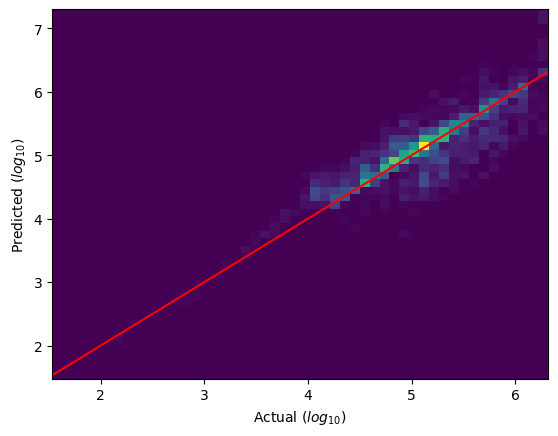

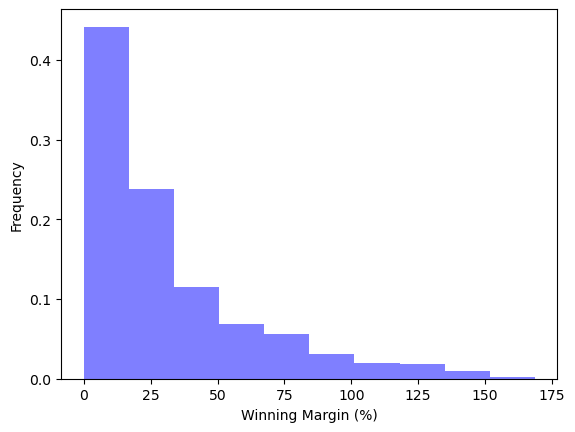

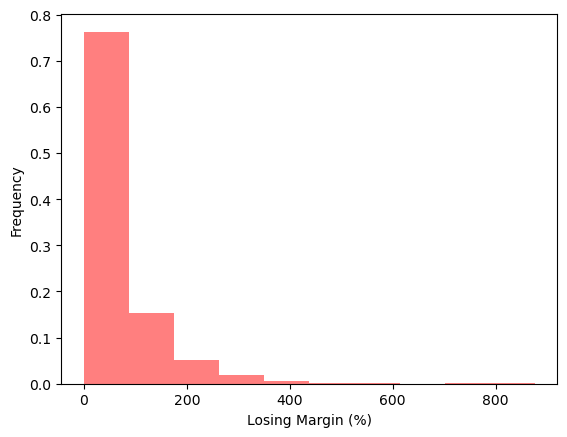

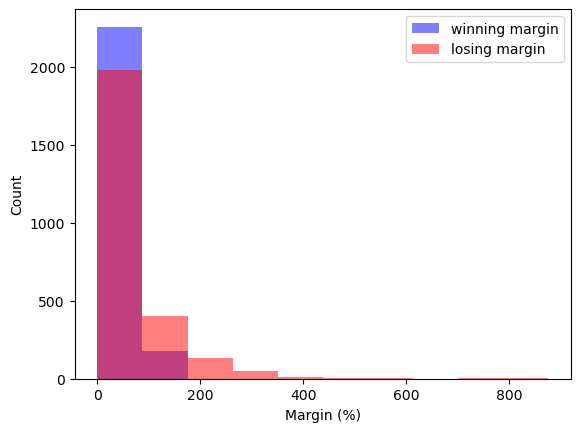

Latest
Aggregate predictions: 95,115,994
Aggregate actual: 83,701,394
Aggregate incurred: 83,382,063
model MALE: 0.201, MSLE: 0.138
incurred MALE: 0.047, MSLE: 0.041
vsInc: 10.78%
Weighted vsInc: 9.86%
number of preds: 566


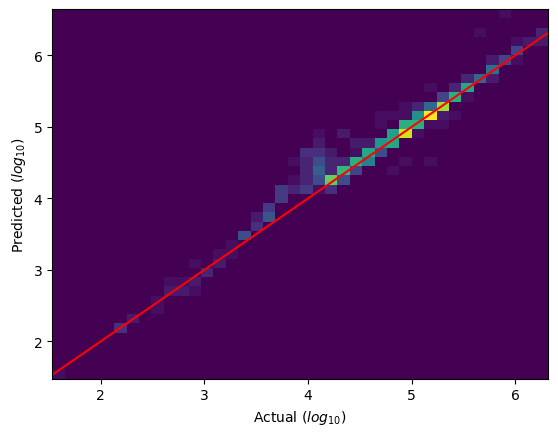

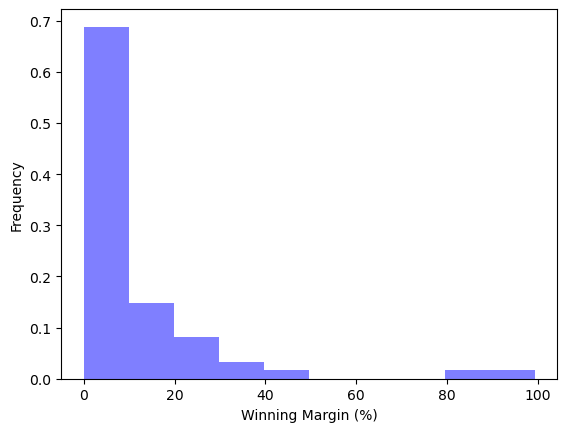

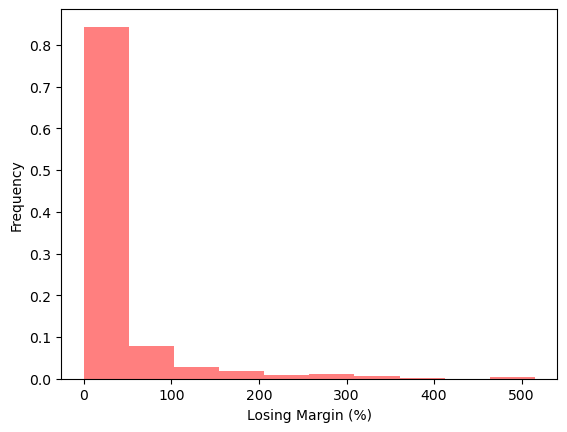

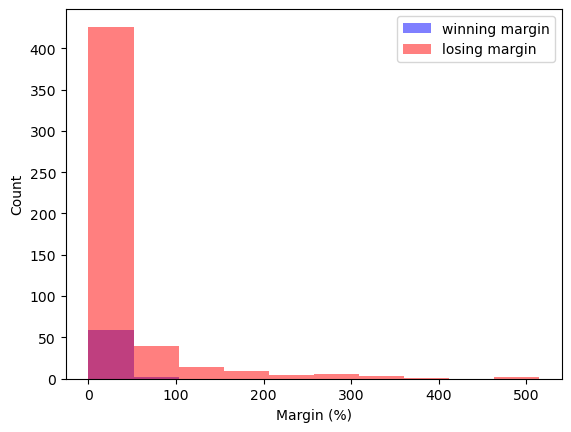

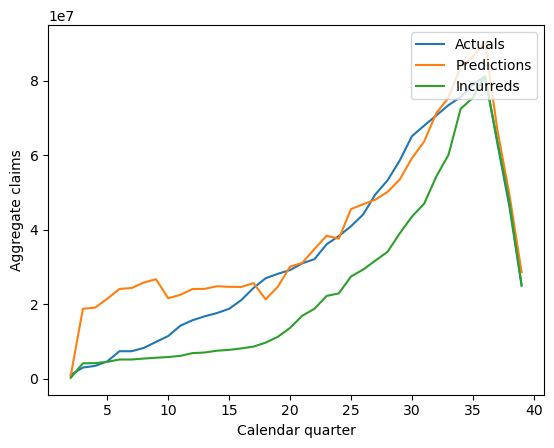

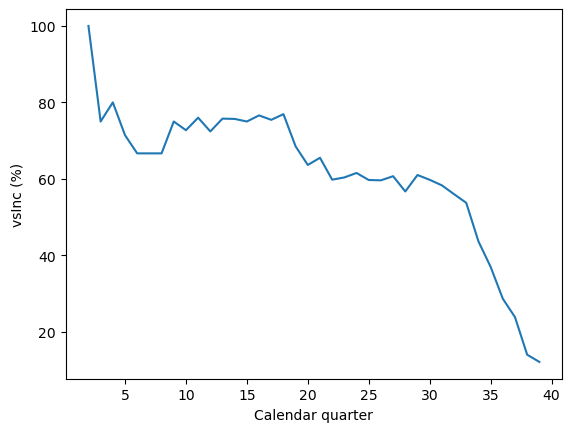

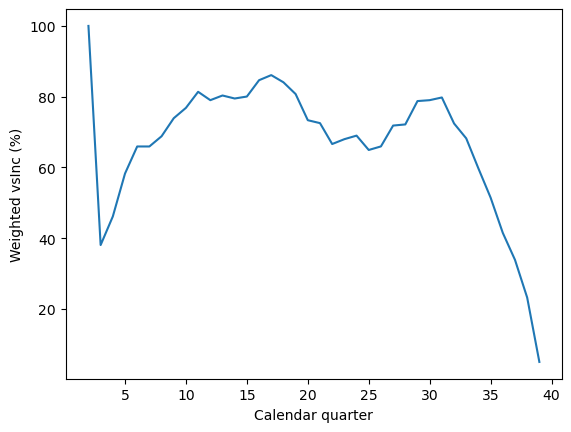

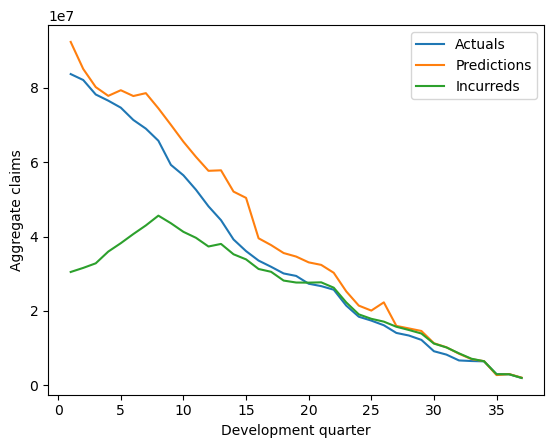

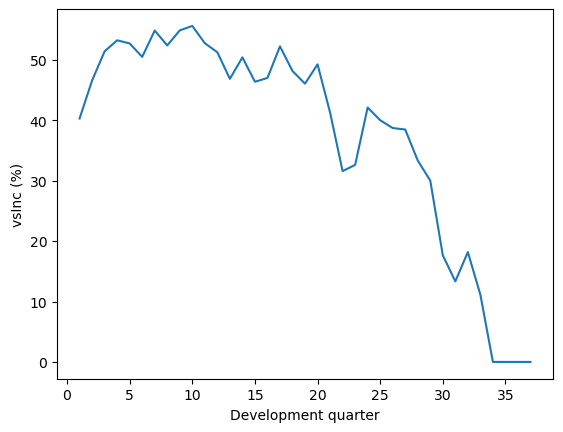

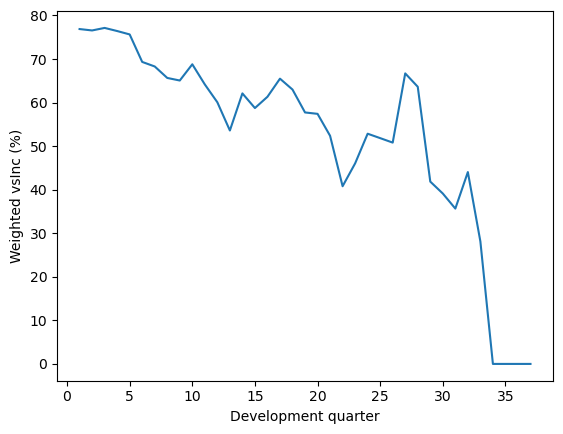

Dev Quarter 1
Aggregate predictions: 92,351,717
Aggregate actual: 83,701,394
Aggregate incurred: 30,468,769
model MALE: 0.820, MSLE: 0.933
incurred MALE: 0.851, MSLE: 1.774
vsInc: 40.28%
Weighted vsInc: 76.88%
number of preds: 566


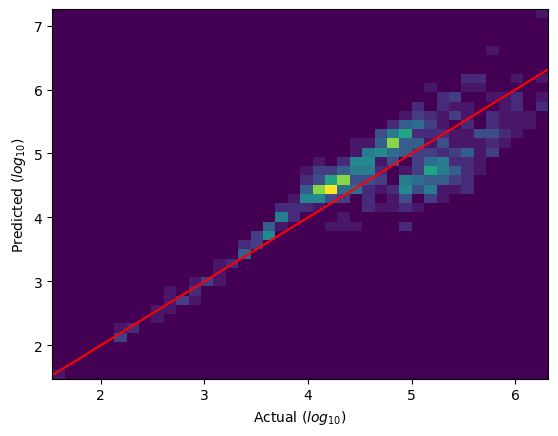

Dev Quarter 5
Aggregate predictions: 79,357,157
Aggregate actual: 74,667,829
Aggregate incurred: 38,212,233
model MALE: 0.515, MSLE: 0.538
incurred MALE: 0.793, MSLE: 1.555
vsInc: 52.71%
Weighted vsInc: 75.64%
number of preds: 351


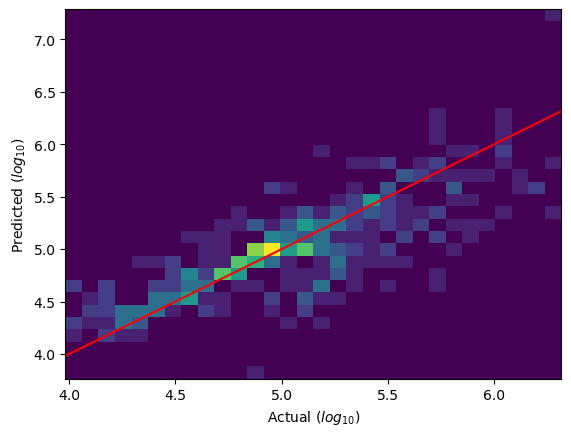

Dev Quarter 10
Aggregate predictions: 65,500,906
Aggregate actual: 56,468,099
Aggregate incurred: 41,264,842
model MALE: 0.290, MSLE: 0.206
incurred MALE: 0.603, MSLE: 1.025
vsInc: 55.61%
Weighted vsInc: 68.79%
number of preds: 205


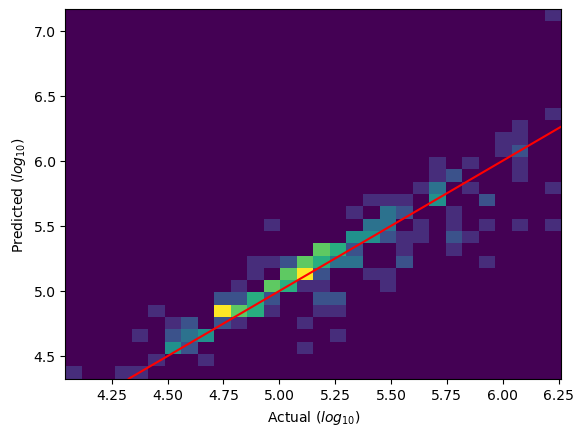

Dev Quarter 16
Aggregate predictions: 39,531,436
Aggregate actual: 33,532,434
Aggregate incurred: 31,275,062
model MALE: 0.252, MSLE: 0.154
incurred MALE: 0.438, MSLE: 0.612
vsInc: 47.00%
Weighted vsInc: 61.33%
number of preds: 100


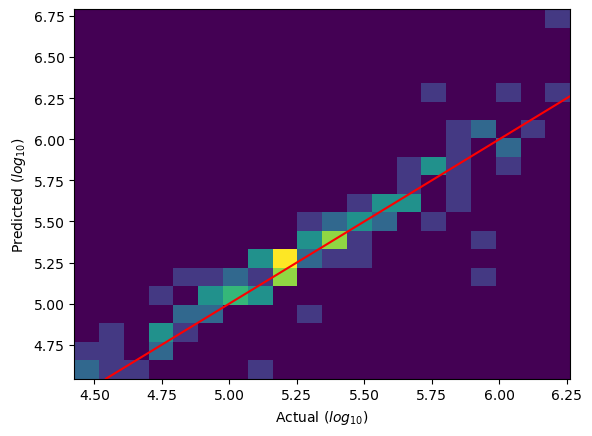

Small
Aggregate predictions: 32,345,710
Aggregate actual: 20,947,859
Aggregate incurred: 21,270,131
model MALE: 0.440, MSLE: 0.341
incurred MALE: 0.112, MSLE: 0.067
vsInc: 14.27%
Weighted vsInc: 17.52%
number of preds: 932


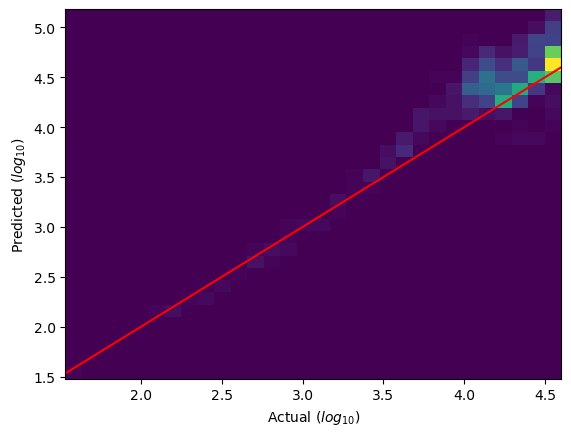

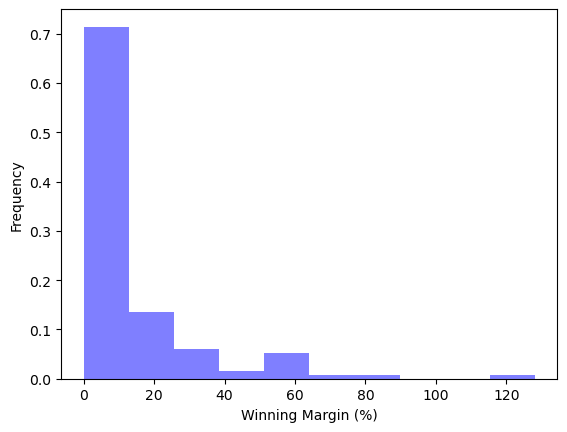

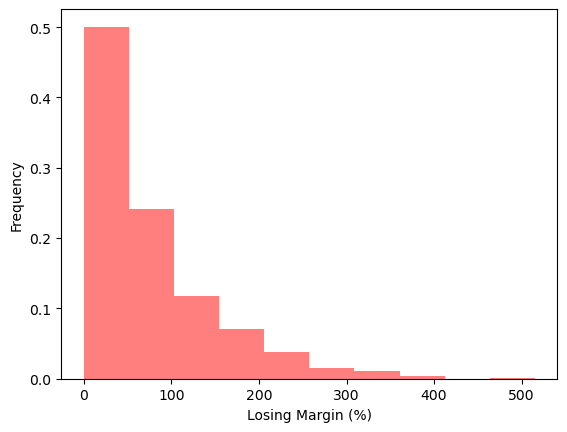

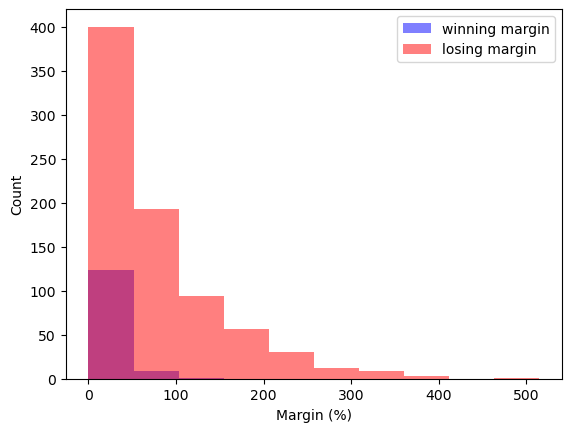

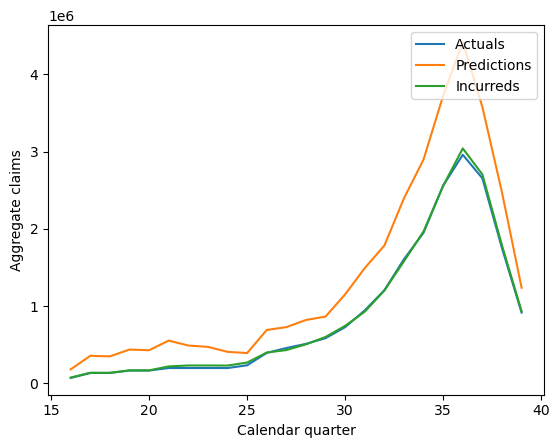

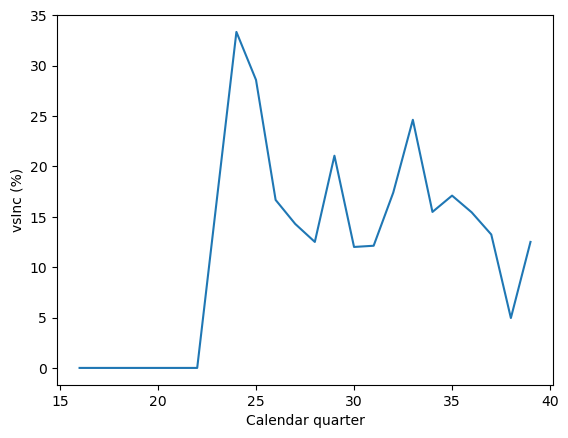

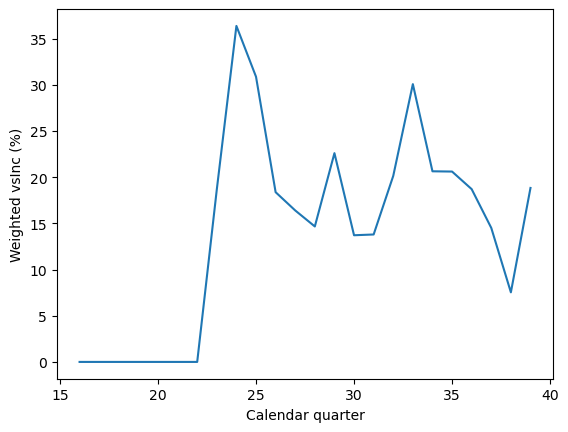

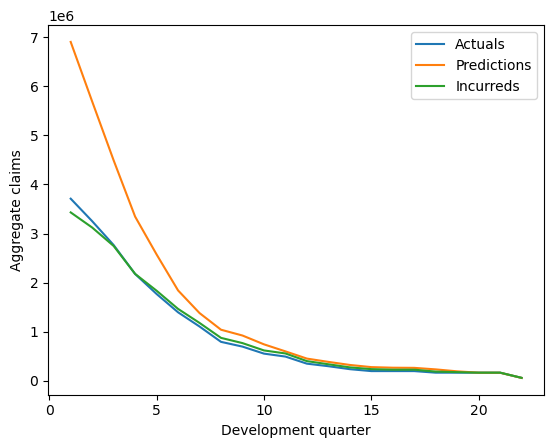

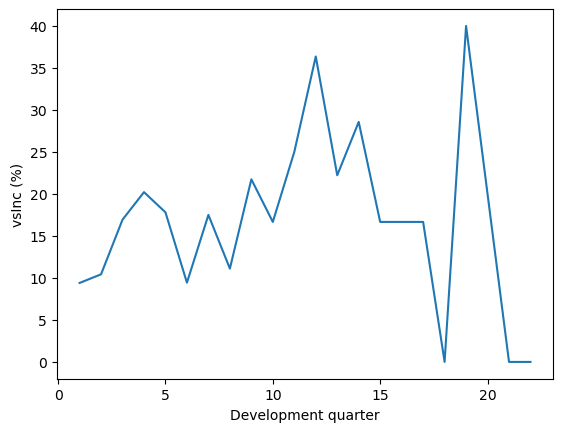

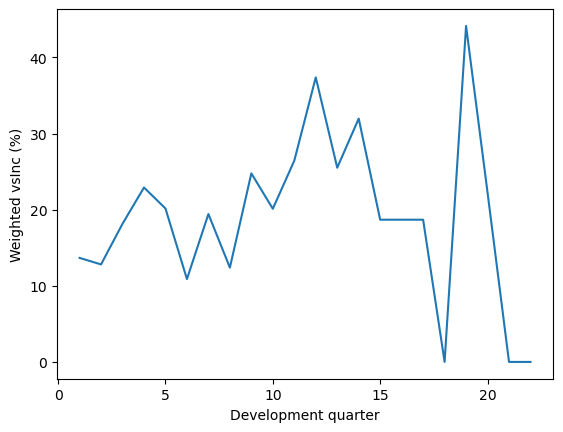

Medium
Aggregate predictions: 557,442,847
Aggregate actual: 544,431,410
Aggregate incurred: 390,430,465
model MALE: 0.436, MSLE: 0.422
incurred MALE: 0.715, MSLE: 1.340
vsInc: 52.44%
Weighted vsInc: 57.58%
number of preds: 3295


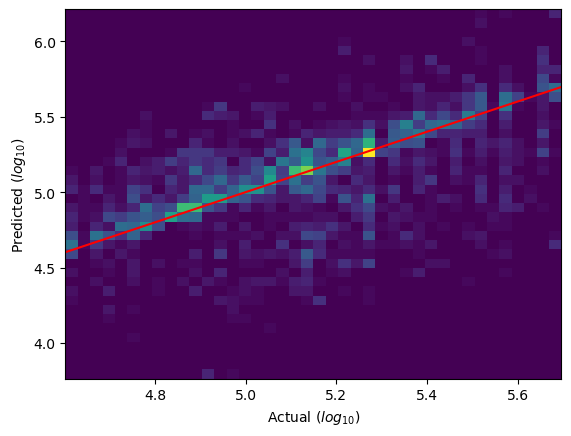

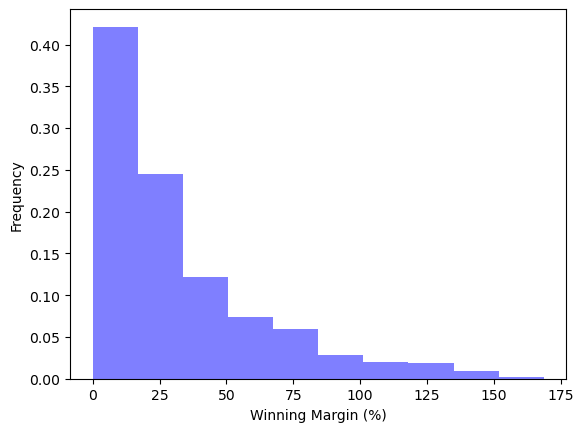

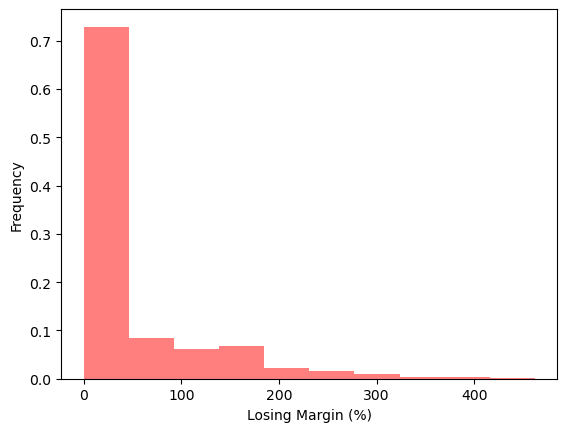

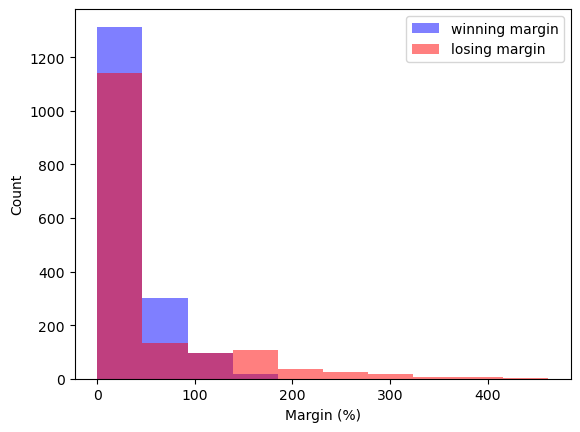

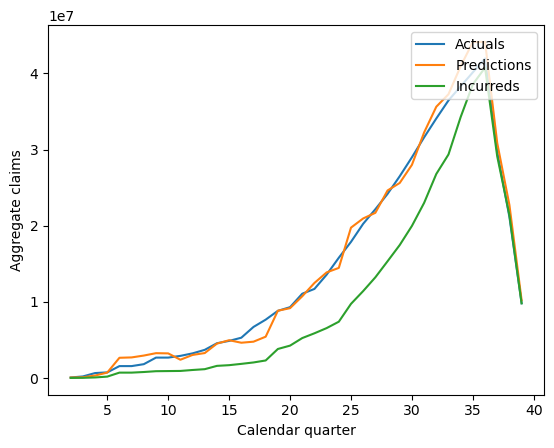

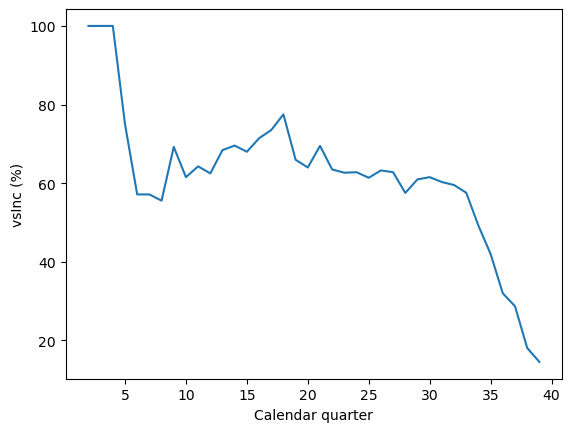

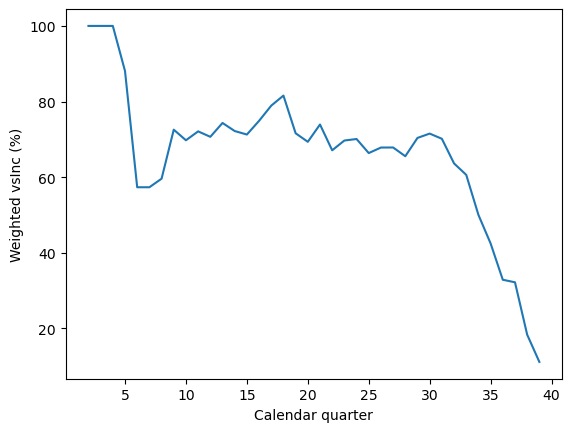

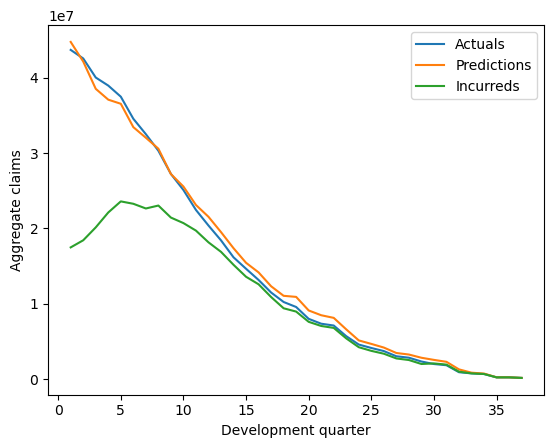

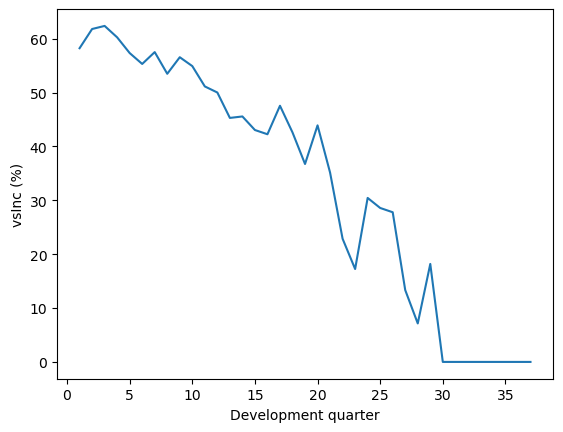

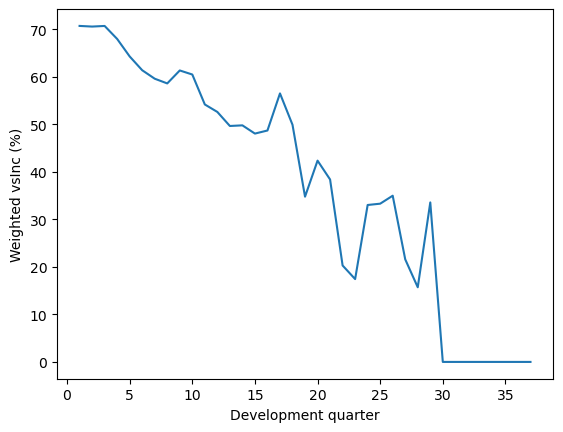

Large
Aggregate predictions: 900,109,839
Aggregate actual: 734,621,502
Aggregate incurred: 526,879,841
model MALE: 0.601, MSLE: 0.722
incurred MALE: 1.113, MSLE: 2.200
vsInc: 71.71%
Weighted vsInc: 71.22%
number of preds: 799


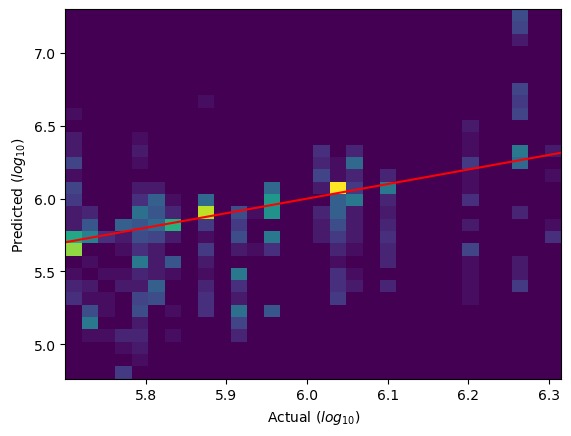

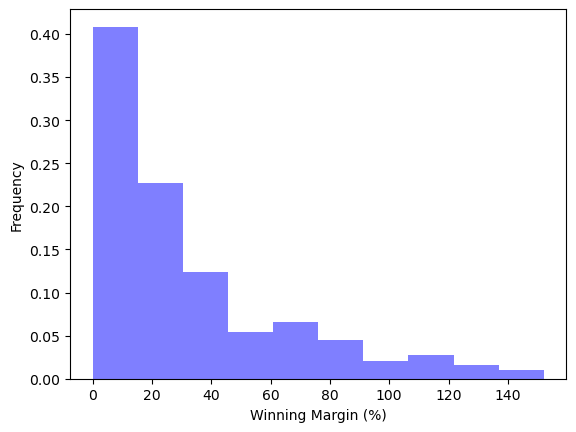

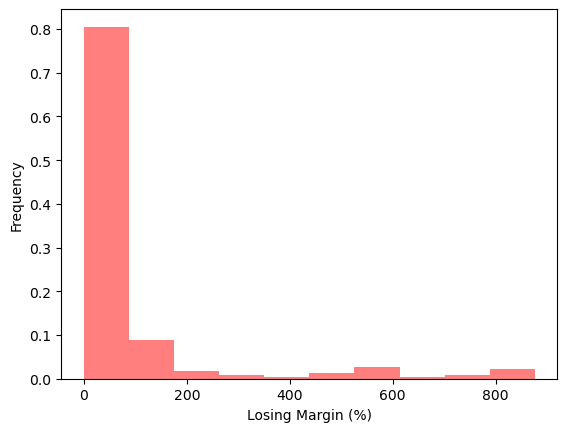

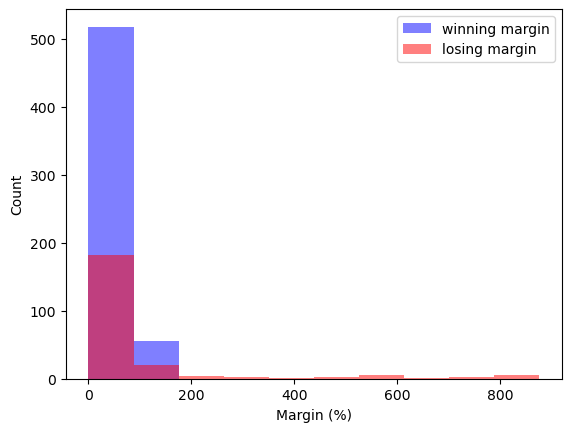

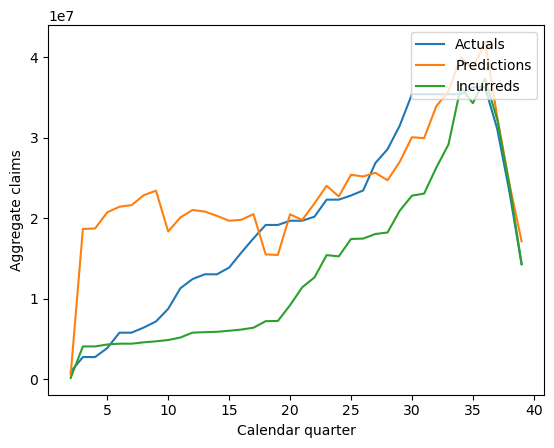

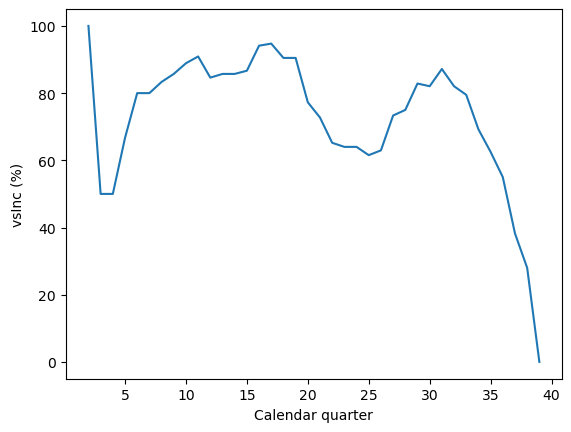

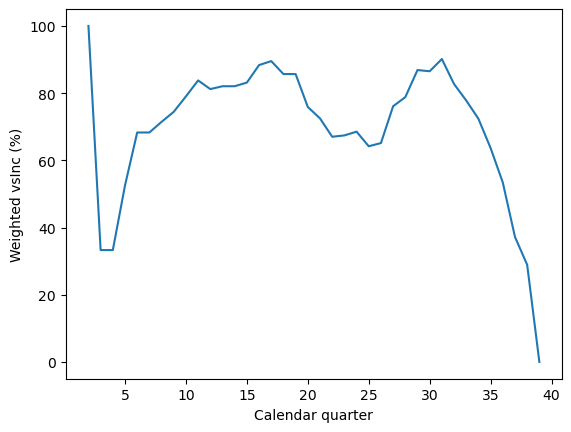

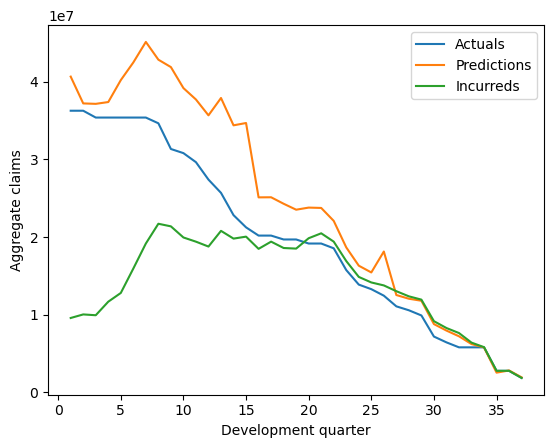

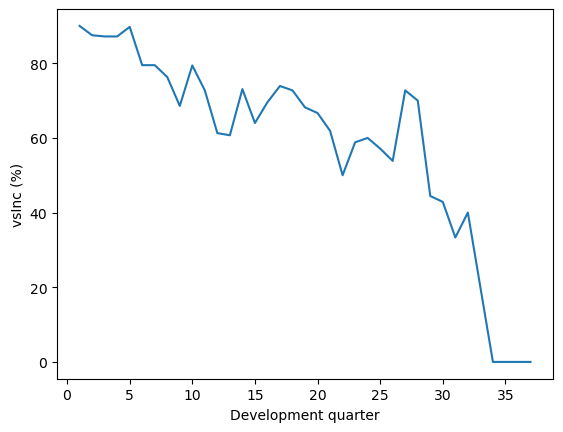

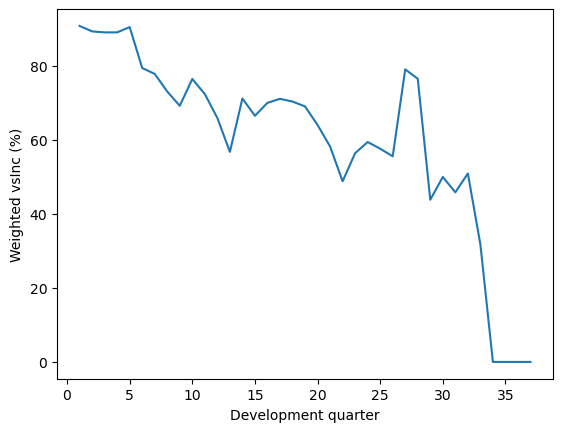

Small Latest
Aggregate predictions: 5,060,676
Aggregate actual: 3,710,117
Aggregate incurred: 3,759,796
model MALE: 0.336, MSLE: 0.264
incurred MALE: 0.026, MSLE: 0.003
vsInc: 7.26%
Weighted vsInc: 8.20%
number of preds: 234


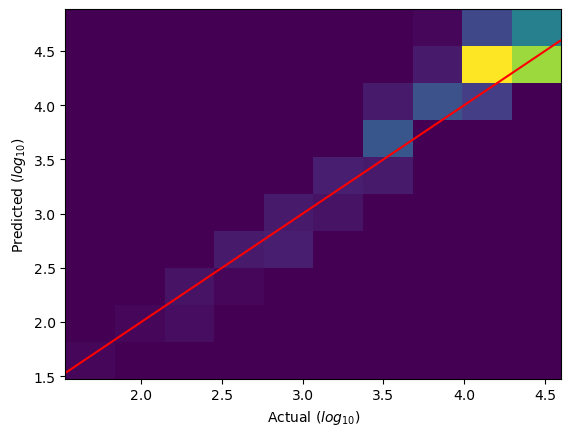

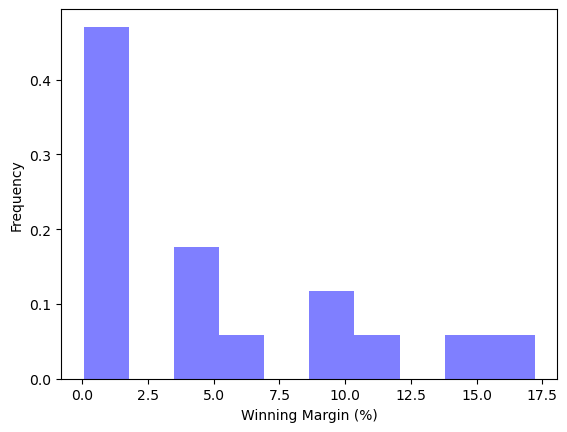

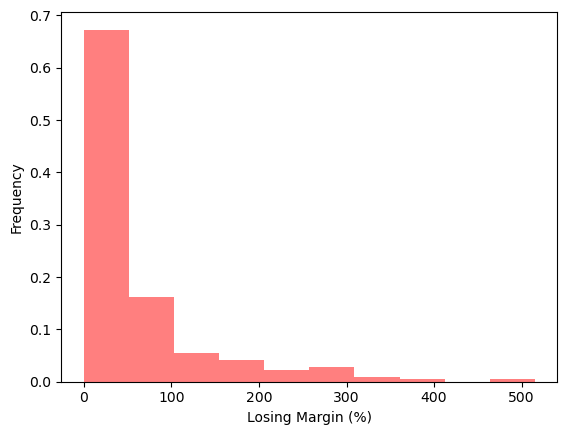

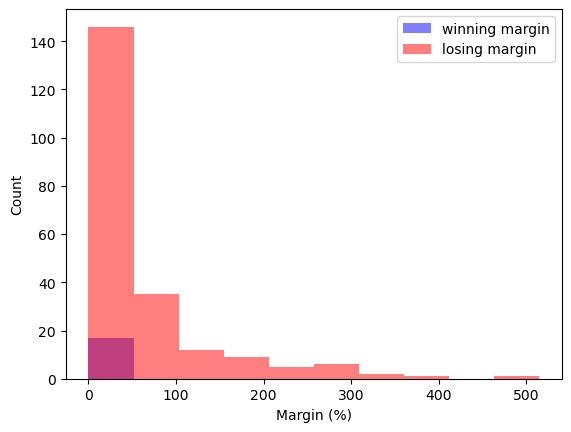

Medium Latest
Aggregate predictions: 45,889,751
Aggregate actual: 43,720,494
Aggregate incurred: 43,306,617
model MALE: 0.098, MSLE: 0.037
incurred MALE: 0.065, MSLE: 0.075
vsInc: 13.70%
Weighted vsInc: 12.11%
number of preds: 292


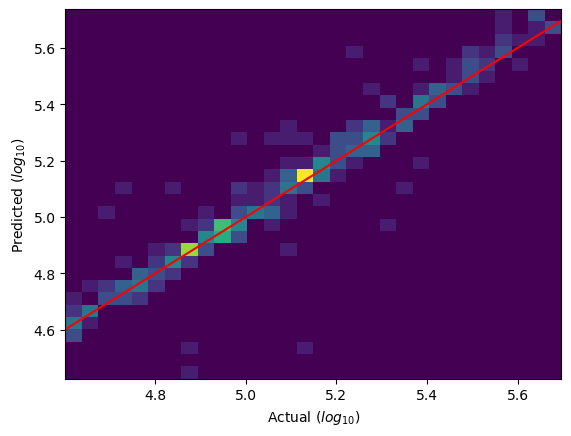

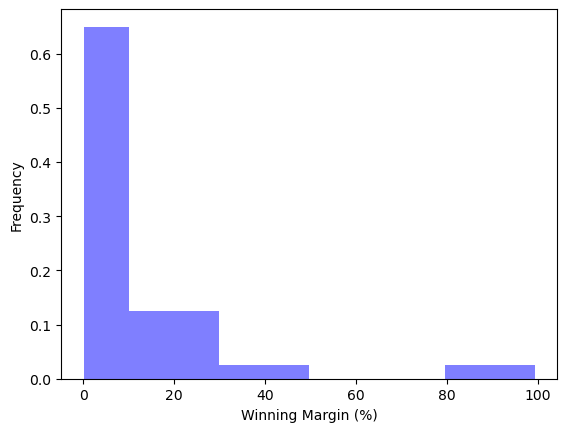

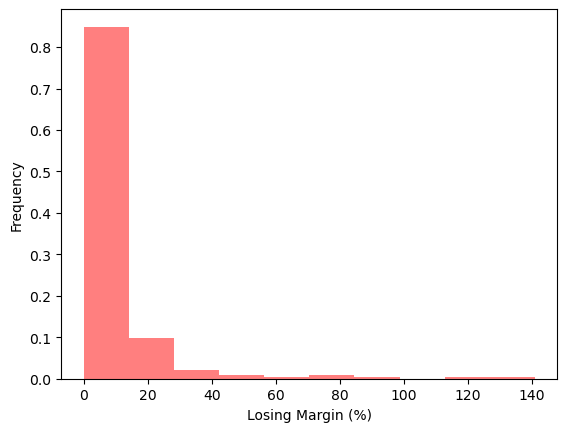

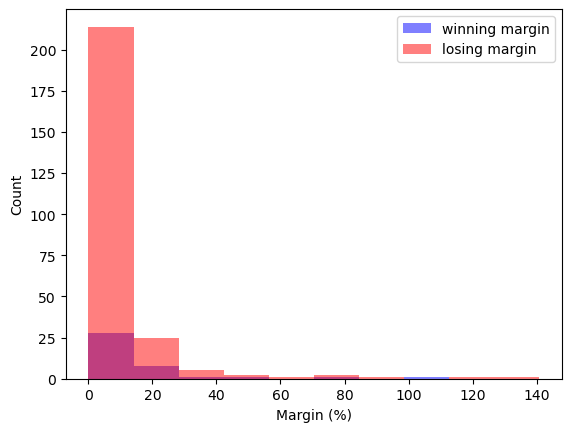

Large Latest
Aggregate predictions: 44,165,567
Aggregate actual: 36,270,783
Aggregate incurred: 36,315,650
model MALE: 0.158, MSLE: 0.144
incurred MALE: 0.031, MSLE: 0.014
vsInc: 10.00%
Weighted vsInc: 7.32%
number of preds: 40


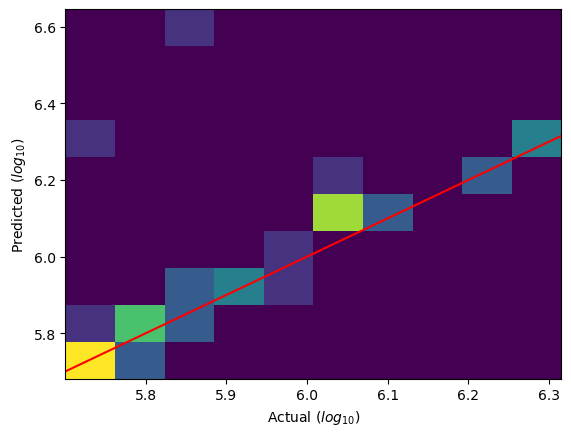

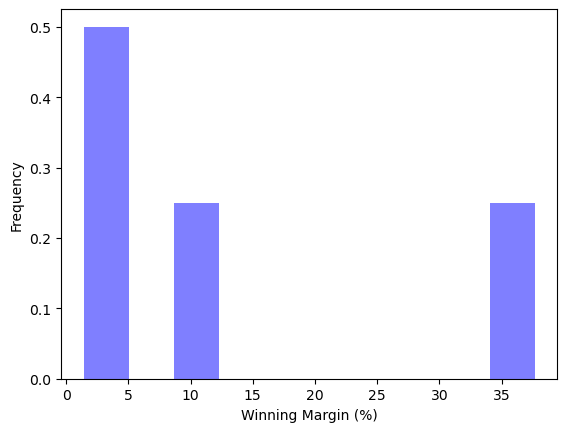

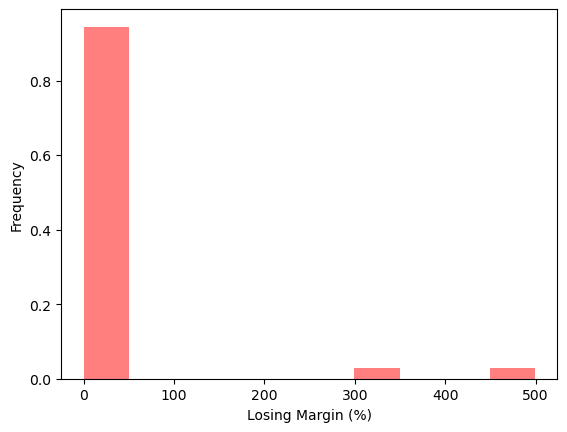

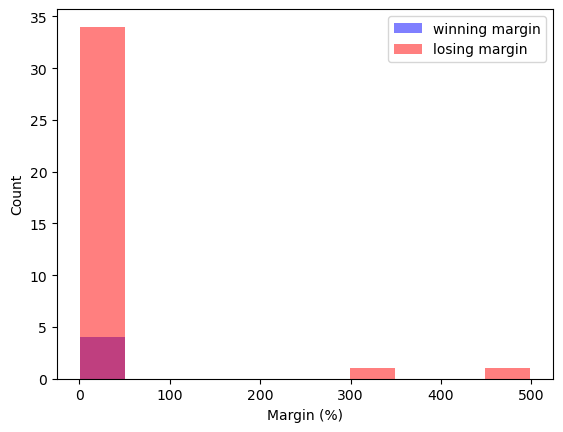

In [2]:
torch.manual_seed(1)

fp_in = 'Datasets/Python Inputs/noInf_WithInc_seed_20201006/'
fp_out = 'Results/results.csv'

# Hyperparameter values to tune (constants)
target_cols = ['log_m']
criterions = [torch.nn.MSELoss()]
types = ['LSTM']
output_layers = ['linear']
nOuts = [1]
epochss = [200]
nonlinearitys = ['relu']
patiences = [10]
normalisations = [False]
include_incurredss = [True]
include_covariatess = [True]
transform_inputss = [False]
model_types = ['RNN']

# Hyperparameter values to tune (variable)
nHiddens = [256, 512]
nLayerss = [2, 3]
batch_sizes = [512]
dropouts = [0.0, 0.2]
learning_rates = [0.00001, 0.0001, 0.001]


hyperparameter_grid = create_grid(target_cols, criterions, types, 
                                  output_layers, nOuts, epochss, nHiddens, 
                                  nLayerss, patiences, batch_sizes, 
                                  learning_rates, nonlinearitys, dropouts, 
                                  normalisations, include_incurredss, 
                                  include_covariatess, transform_inputss, model_types)

cross_validate(fp_in, fp_out, hyperparameter_grid)

## Without Covariates

In [ ]:
torch.manual_seed(1)

fp_in = 'Datasets/Python Inputs/noInf_WithInc_seed_20201006/'
fp_out = 'Results/results.csv'

# Hyperparameter values to tune (constants)
target_cols = ['log_m']
criterions = [torch.nn.MSELoss()]
types = ['LSTM']
output_layers = ['linear']
nOuts = [1]
epochss = [200]
nonlinearitys = ['relu']
patiences = [10]
normalisations = [False]
include_incurredss = [True]
include_covariatess = [False]
transform_inputss = [False]
model_types = ['RNN']

# Hyperparameter values to tune (variable)
nHiddens = [256, 512]
nLayerss = [2, 3]
batch_sizes = [512]
dropouts = [0.0, 0.2]
learning_rates = [0.00001, 0.0001, 0.001]


hyperparameter_grid = create_grid(target_cols, criterions, types, 
                                  output_layers, nOuts, epochss, nHiddens, 
                                  nLayerss, patiences, batch_sizes, 
                                  learning_rates, nonlinearitys, dropouts, 
                                  normalisations, include_incurredss, 
                                  include_covariatess, transform_inputss, model_types)

cross_validate(fp_in, fp_out, hyperparameter_grid)

## Test Set

In [ ]:
torch.manual_seed(1)

fp_in = 'Datasets/Python Inputs/noInf_WithInc_seed_20201006/'
fp_out = 'Results/Test Set Preds RNN WithInc WithCov.csv'

# Hyperparameter values to tune (constants)
target_cols = ['log_m']
criterions = [torch.nn.MSELoss()]
types = ['LSTM']
output_layers = ['linear']
nOuts = [1]
epochss = [200]
nonlinearitys = ['relu']
patiences = [10]
normalisations = [False]
include_incurredss = [True]
include_covariatess = [True]
transform_inputss = [False]
model_types = ['RNN']

# Hyperparameter values to tune (variable)
nHiddens = [512]
nLayerss = [2]
batch_sizes = [512]
dropouts = [0.0]
learning_rates = [0.001]


hyperparameter_grid = create_grid(target_cols, criterions, types, 
                                  output_layers, nOuts, epochss, nHiddens, 
                                  nLayerss, patiences, batch_sizes, 
                                  learning_rates, nonlinearitys, dropouts, 
                                  normalisations, include_incurredss, 
                                  include_covariatess, transform_inputss, model_types)

hp_comb = hyperparameter_grid[0]

final_test(fp_in, fp_out, hp_comb, iterations=50, verbose=True, 
           pretrained=False)

# Without Incurreds

## With Covariates

In [ ]:
torch.manual_seed(1)

fp_in = 'Datasets/Python Inputs/noInf_WithInc_seed_20201006/'
fp_out = 'Results/results.csv'

# Hyperparameter values to tune (constants)
target_cols = ['log_m']
criterions = [torch.nn.MSELoss()]
types = ['LSTM']
output_layers = ['linear']
nOuts = [1]
epochss = [200]
nonlinearitys = ['relu']
patiences = [10]
normalisations = [False]
include_incurredss = [False]
include_covariatess = [True]
transform_inputss = [False]
model_types = ['RNN']

# Hyperparameter values to tune (variable)
nHiddens = [256, 512]
nLayerss = [2, 3]
batch_sizes = [512]
dropouts = [0.0, 0.2]
learning_rates = [0.00001, 0.0001, 0.001]


hyperparameter_grid = create_grid(target_cols, criterions, types, 
                                  output_layers, nOuts, epochss, nHiddens, 
                                  nLayerss, patiences, batch_sizes, 
                                  learning_rates, nonlinearitys, dropouts, 
                                  normalisations, include_incurredss, 
                                  include_covariatess, transform_inputss, model_types)

cross_validate(fp_in, fp_out, hyperparameter_grid)

## Without Covariates


Trying hyperparameter combination: {'target_col': 'log_m', 'criterion': MSELoss(), 'type': 'LSTM', 'output_layer': 'linear', 'nOut': 1, 'epochs': 200, 'nHidden': 256, 'nLayers': 2, 'patience': 10, 'batch_size': 512, 'lr': 1e-05, 'nonlinearity': 'relu', 'dropout': 0.0, 'normalisation': False, 'include_incurreds': False, 'include_covariates': False, 'transform_inputs': False, 'model_type': 'RNN'}
Epoch 0: training loss = 1.604, vsInc = 27.94%, weighted vsInc = 45.39%, UIE = 0.28%
Validation
loss = 2.823, vsInc = 27.22%, weighted vsInc = 40.94%, UIE = 0.04%
Epoch 1: training loss = 1.505, vsInc = 28.34%, weighted vsInc = 45.78%, UIE = 0.30%
Validation
loss = 2.59, vsInc = 27.95%, weighted vsInc = 41.60%, UIE = 0.04%
Epoch 2: training loss = 1.408, vsInc = 28.65%, weighted vsInc = 46.16%, UIE = 0.40%
Validation
loss = 2.359, vsInc = 28.57%, weighted vsInc = 42.20%, UIE = 0.04%
Epoch 3: training loss = 1.308, vsInc = 28.99%, weighted vsInc = 46.55%, UIE = 0.58%
Validation
loss = 2.1, vsInc

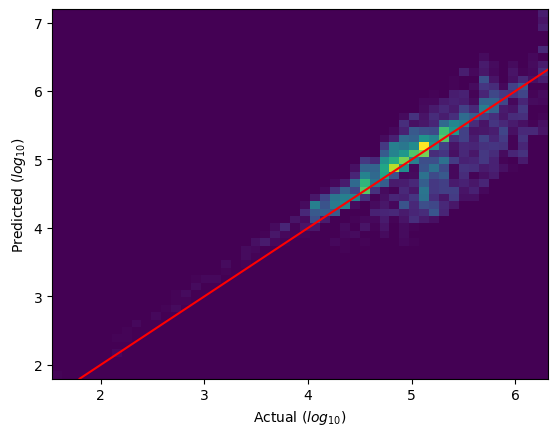

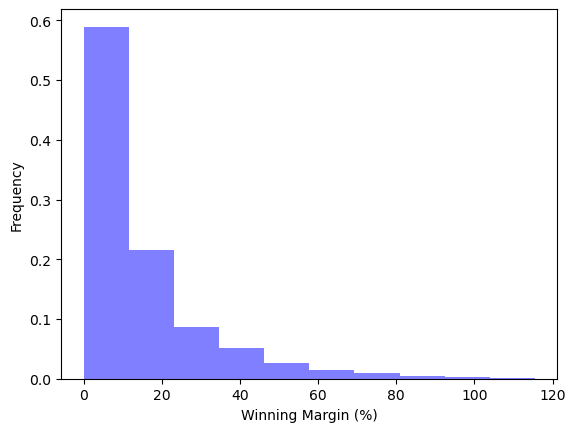

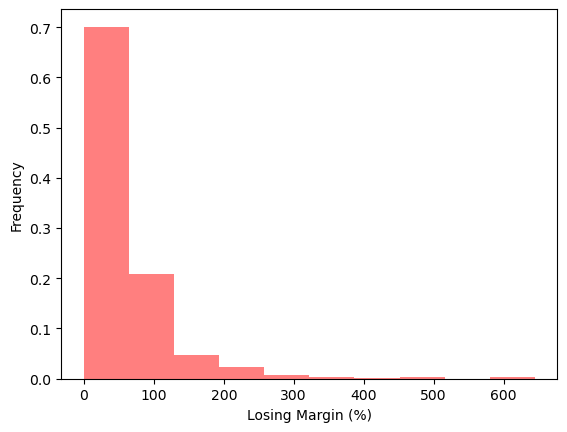

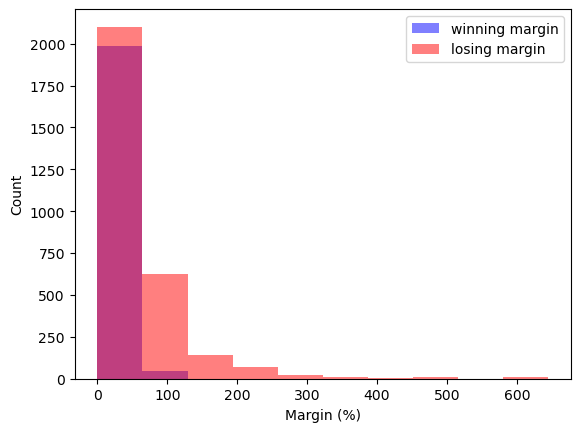

Latest
Aggregate predictions: 82,152,698
Aggregate actual: 83,701,394
Aggregate incurred: 83,382,063
model MALE: 0.188, MSLE: 0.088
incurred MALE: 0.047, MSLE: 0.041
vsInc: 6.01%
Weighted vsInc: 6.27%
number of preds: 566


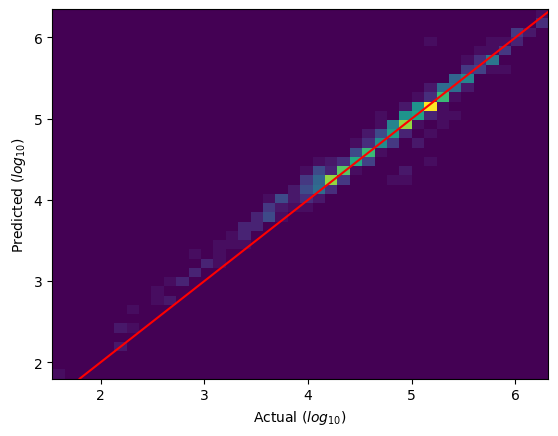

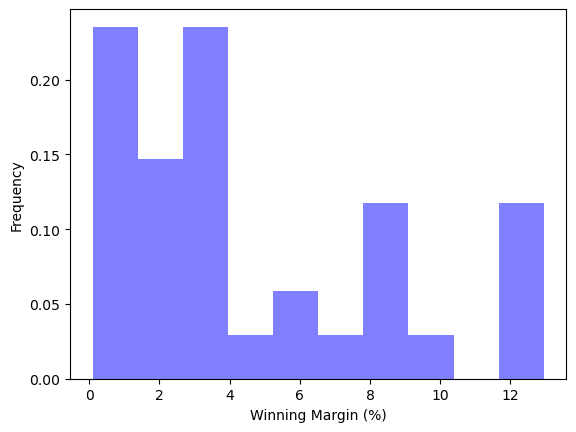

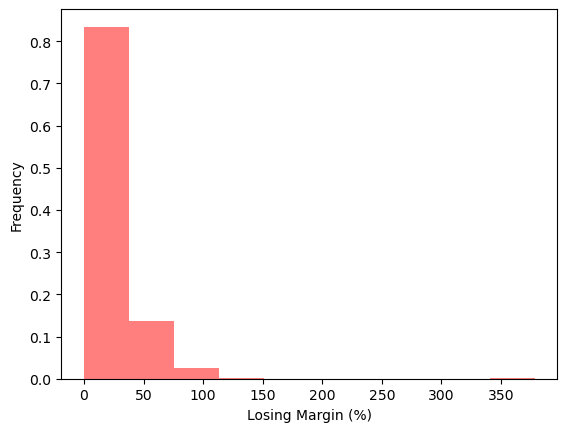

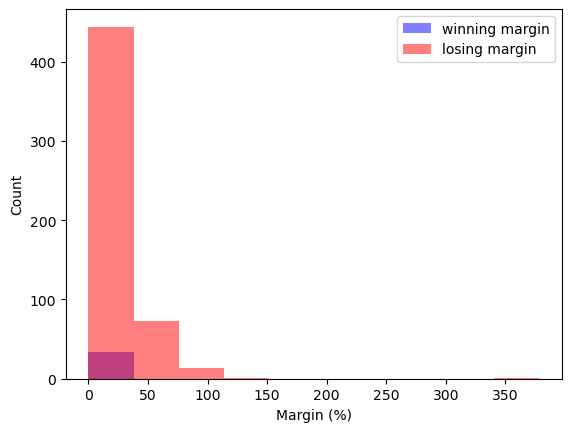

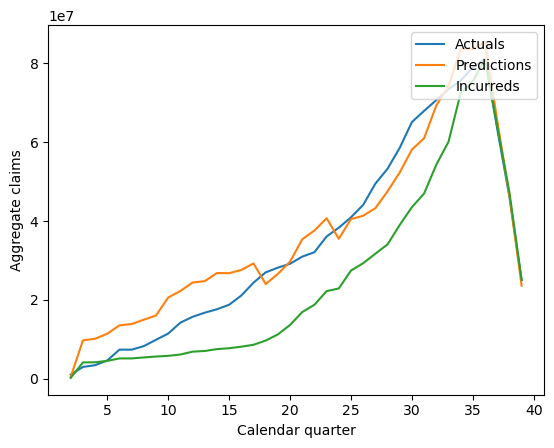

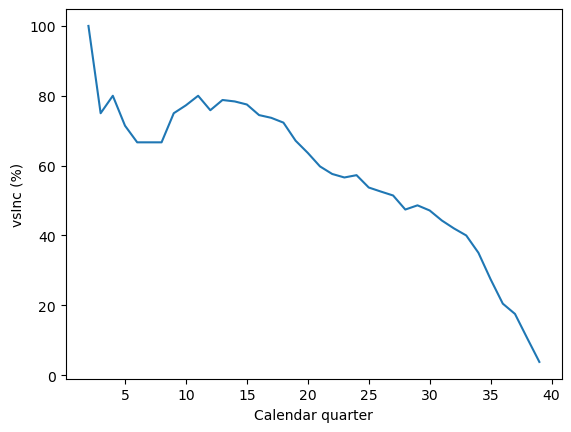

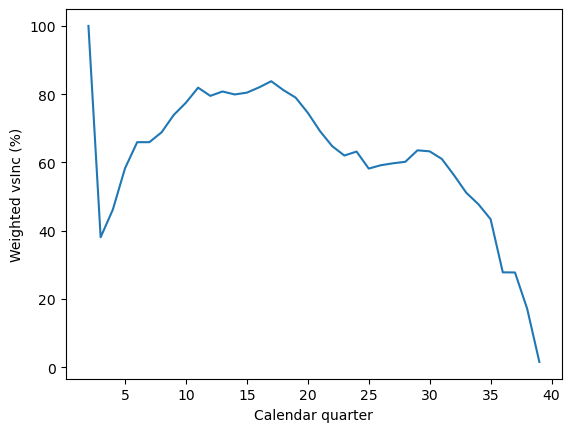

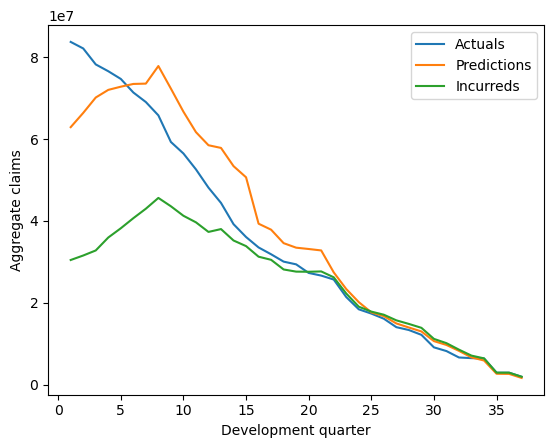

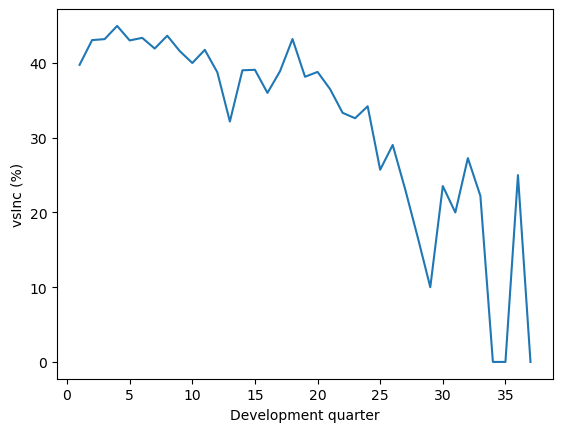

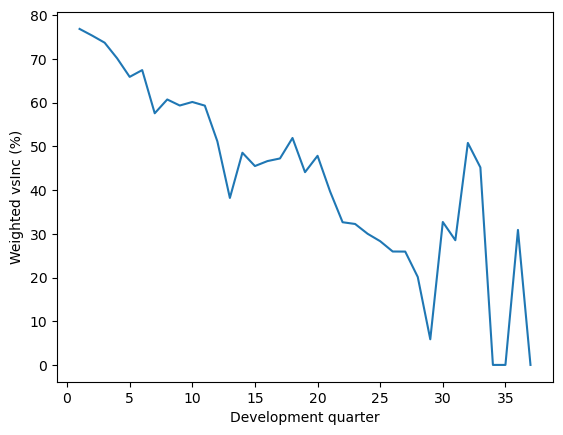

Dev Quarter 1
Aggregate predictions: 62,895,705
Aggregate actual: 83,701,394
Aggregate incurred: 30,468,769
model MALE: 0.862, MSLE: 1.090
incurred MALE: 0.851, MSLE: 1.774
vsInc: 39.75%
Weighted vsInc: 76.87%
number of preds: 566


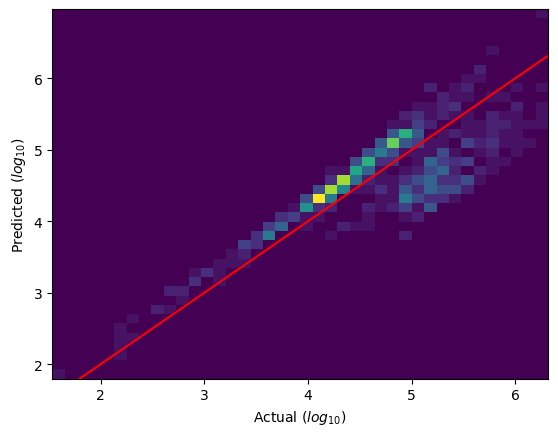

Dev Quarter 5
Aggregate predictions: 72,773,140
Aggregate actual: 74,667,829
Aggregate incurred: 38,212,233
model MALE: 0.728, MSLE: 0.926
incurred MALE: 0.793, MSLE: 1.555
vsInc: 43.02%
Weighted vsInc: 65.90%
number of preds: 351


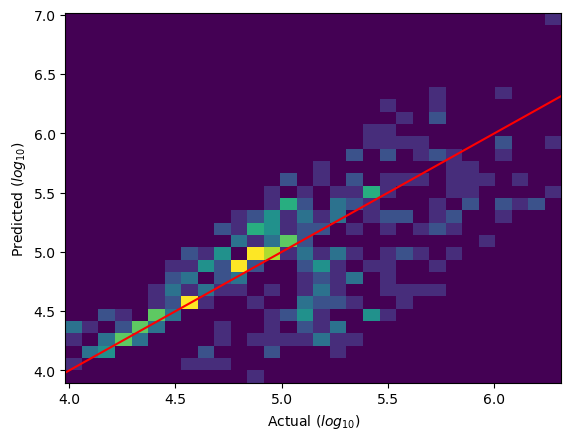

Dev Quarter 10
Aggregate predictions: 66,669,473
Aggregate actual: 56,468,099
Aggregate incurred: 41,264,842
model MALE: 0.575, MSLE: 0.713
incurred MALE: 0.603, MSLE: 1.025
vsInc: 40.00%
Weighted vsInc: 60.16%
number of preds: 205


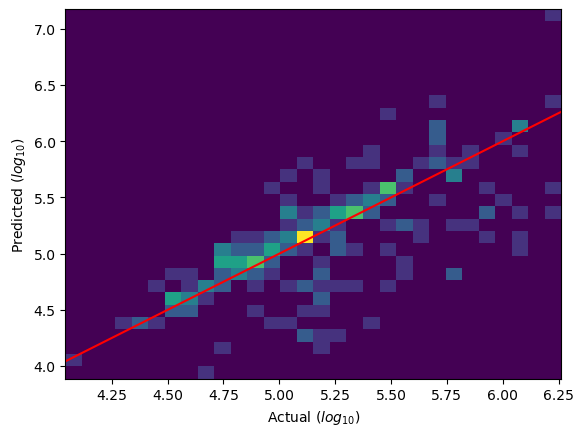

Dev Quarter 16
Aggregate predictions: 39,329,203
Aggregate actual: 33,532,434
Aggregate incurred: 31,275,062
model MALE: 0.475, MSLE: 0.514
incurred MALE: 0.438, MSLE: 0.612
vsInc: 36.00%
Weighted vsInc: 46.64%
number of preds: 100


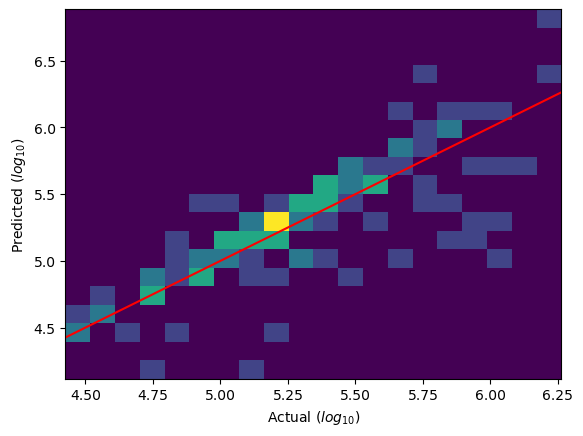

Small
Aggregate predictions: 28,549,829
Aggregate actual: 20,947,859
Aggregate incurred: 21,270,131
model MALE: 0.347, MSLE: 0.198
incurred MALE: 0.112, MSLE: 0.067
vsInc: 12.34%
Weighted vsInc: 15.23%
number of preds: 932


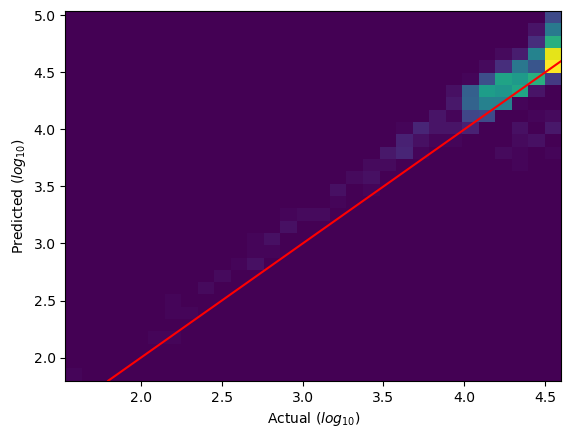

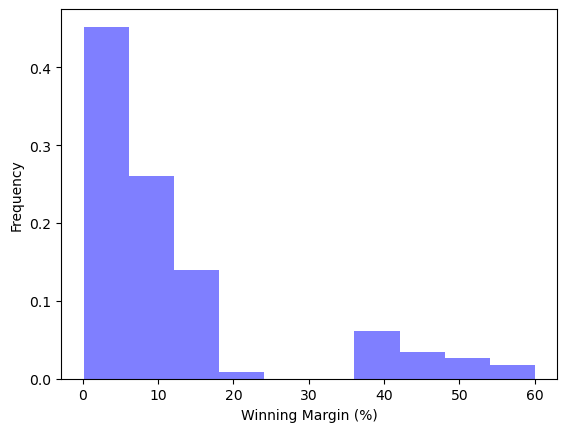

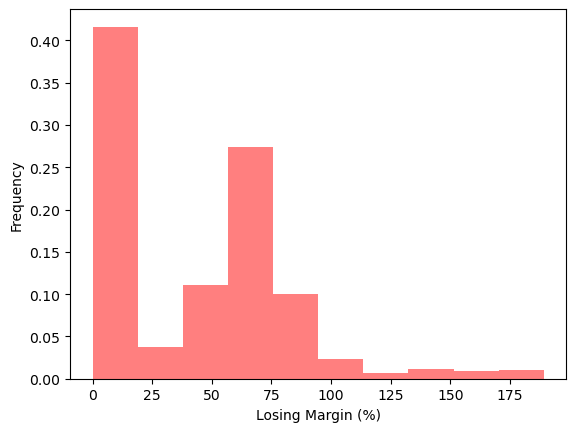

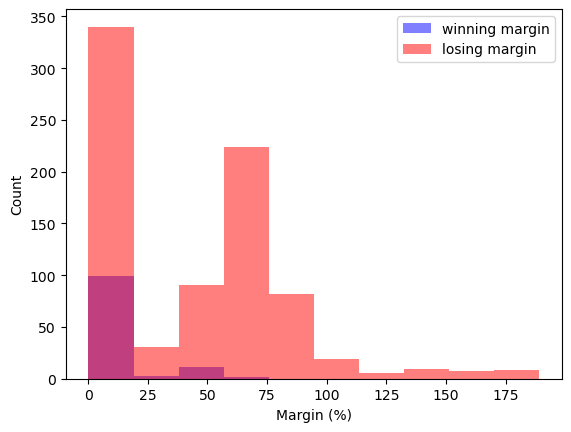

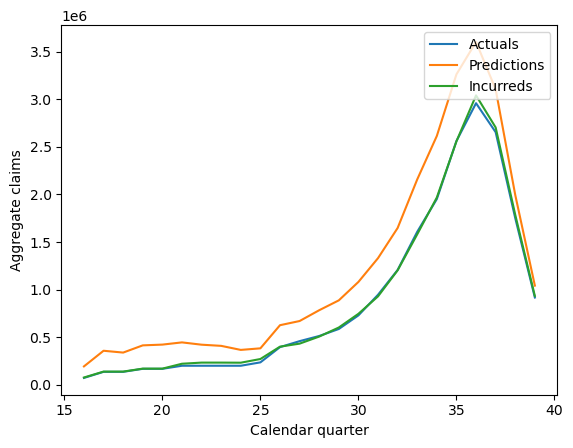

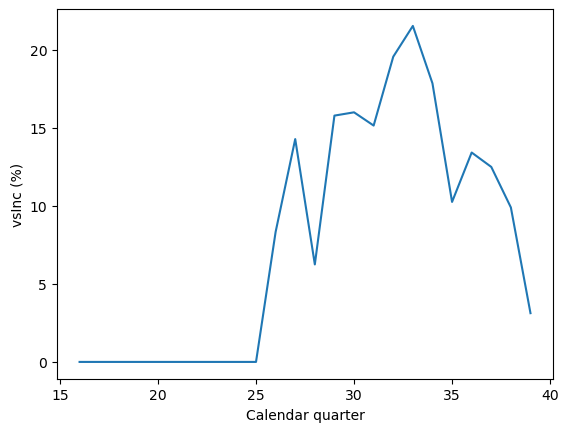

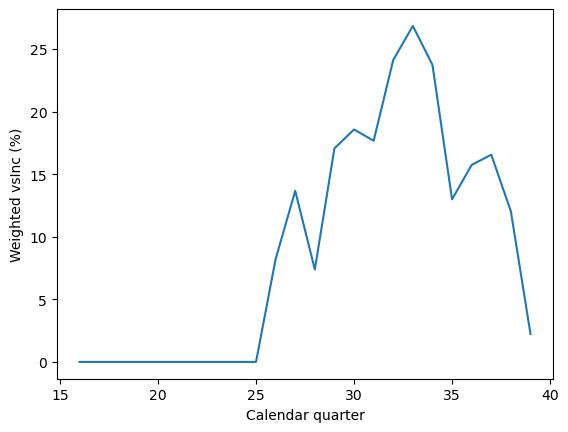

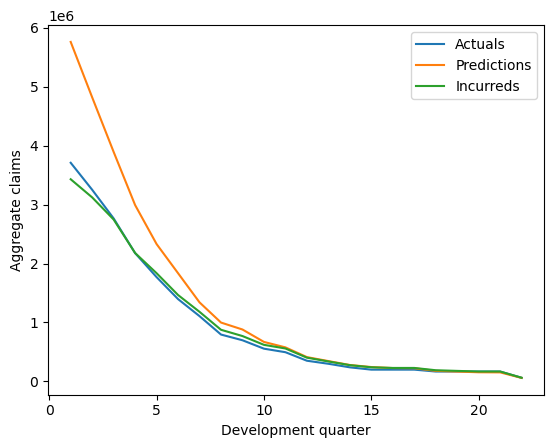

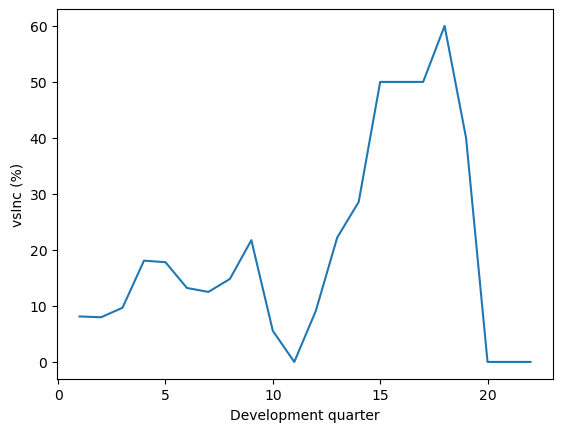

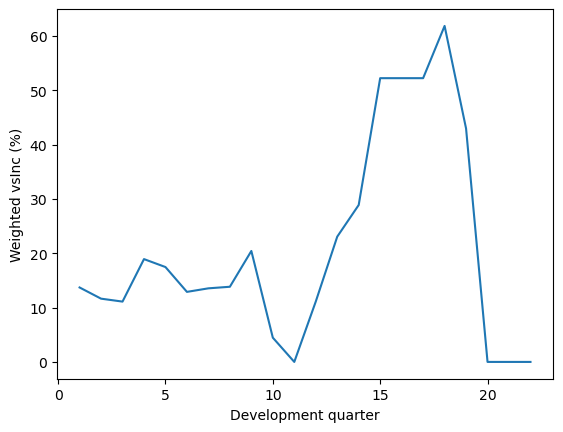

Medium
Aggregate predictions: 559,244,053
Aggregate actual: 544,431,410
Aggregate incurred: 390,430,465
model MALE: 0.678, MSLE: 0.855
incurred MALE: 0.715, MSLE: 1.340
vsInc: 42.88%
Weighted vsInc: 48.16%
number of preds: 3295


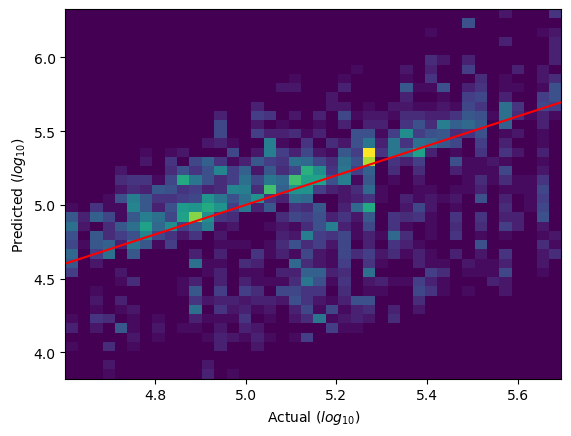

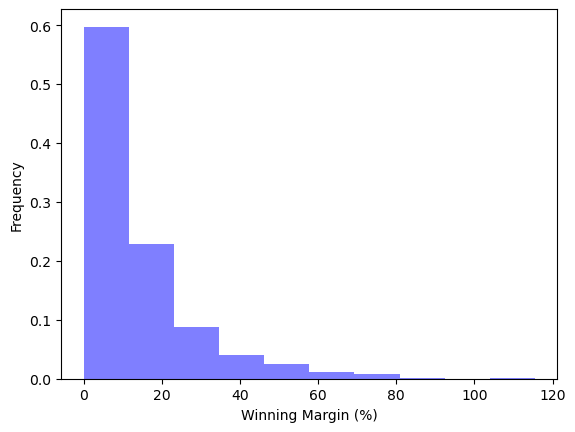

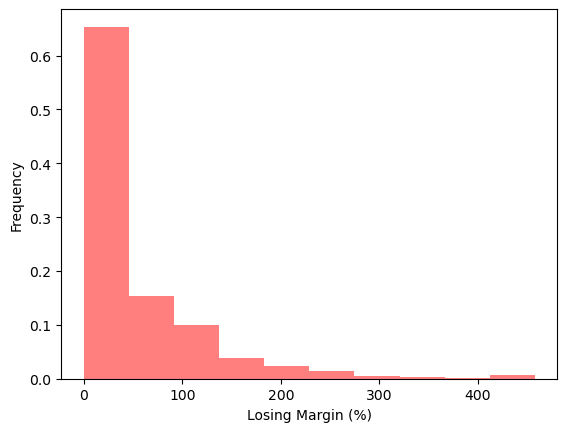

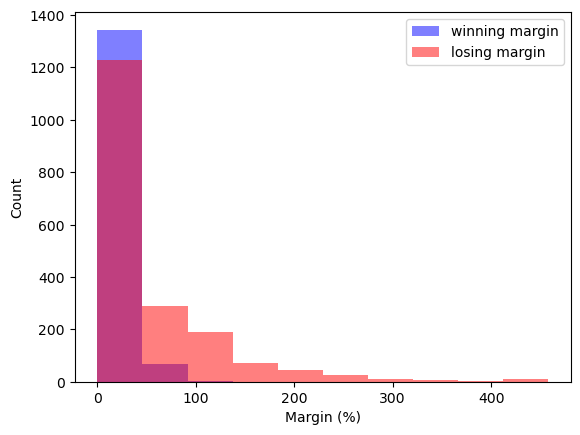

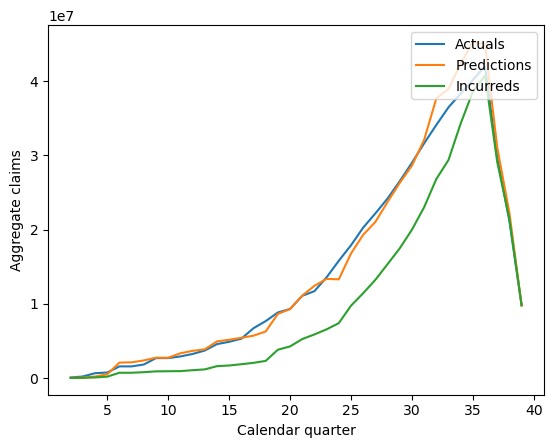

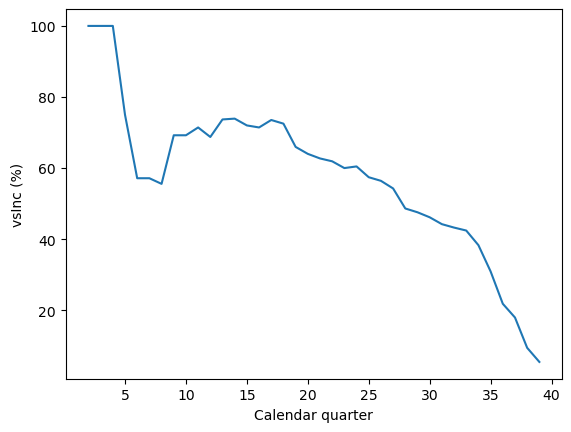

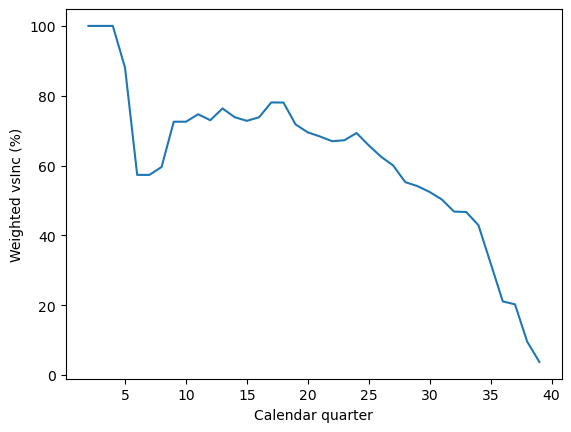

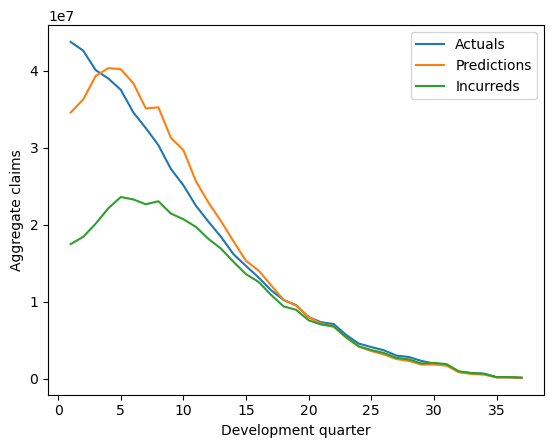

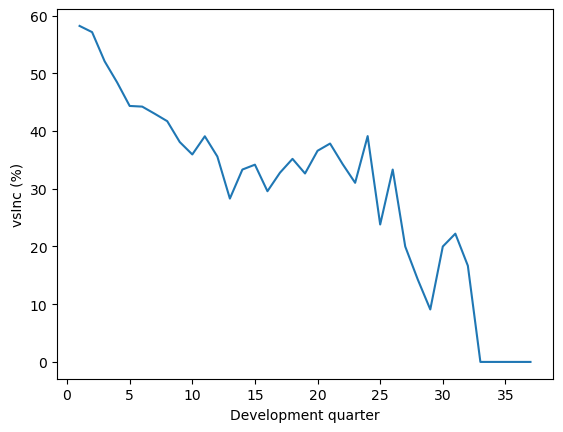

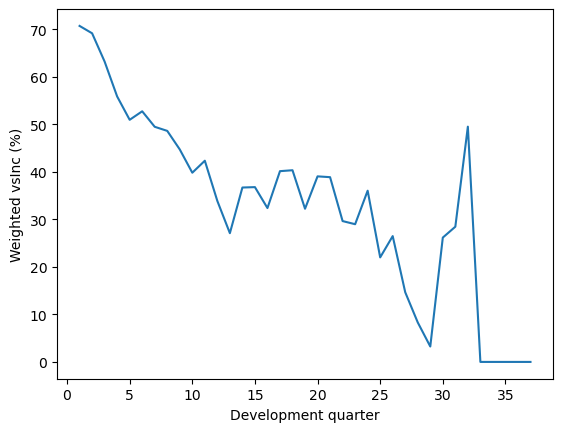

Large
Aggregate predictions: 809,182,356
Aggregate actual: 734,621,502
Aggregate incurred: 526,879,841
model MALE: 0.845, MSLE: 1.196
incurred MALE: 1.113, MSLE: 2.200
vsInc: 62.58%
Weighted vsInc: 62.49%
number of preds: 799


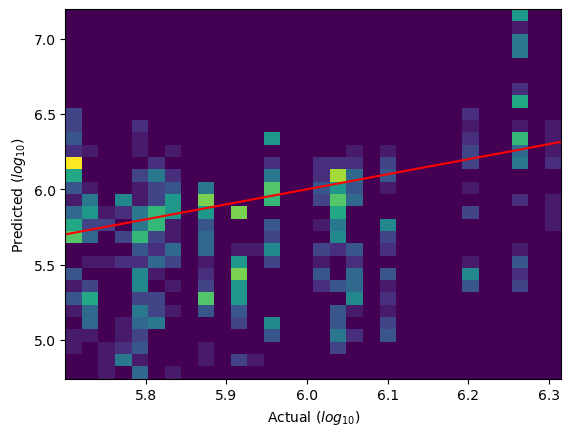

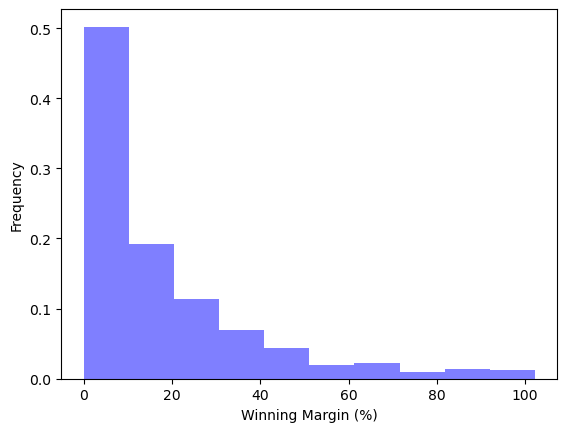

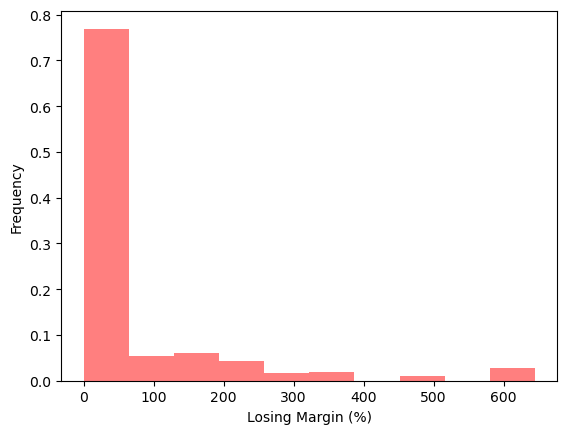

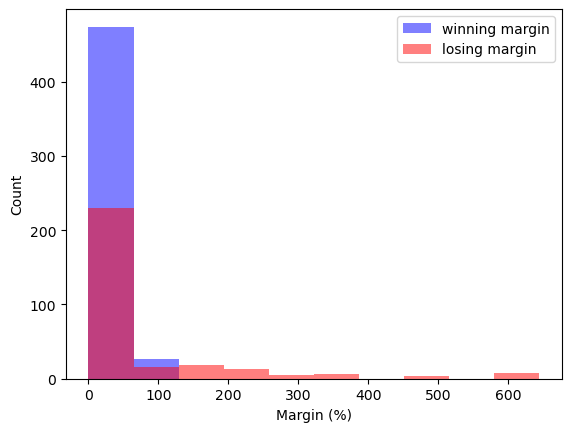

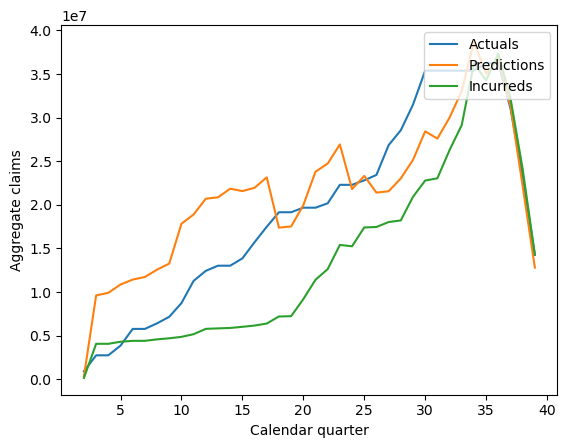

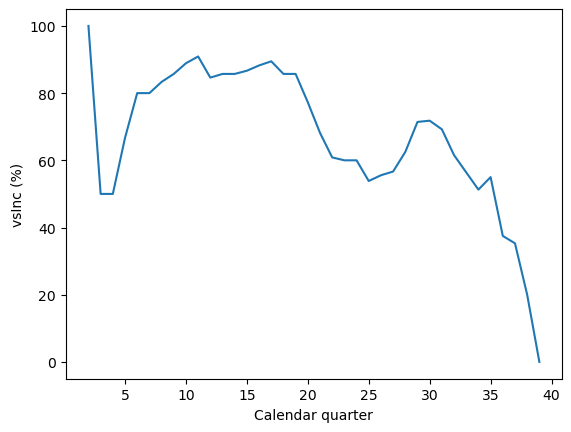

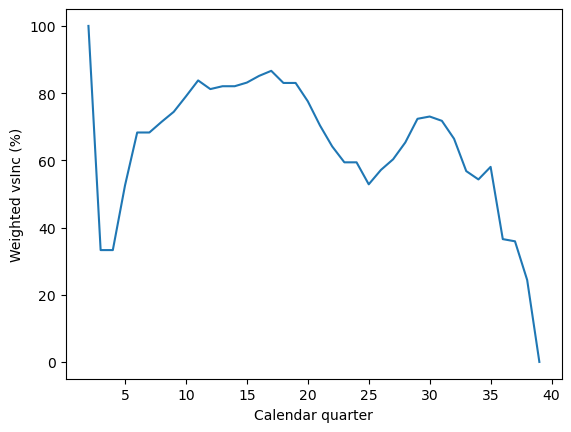

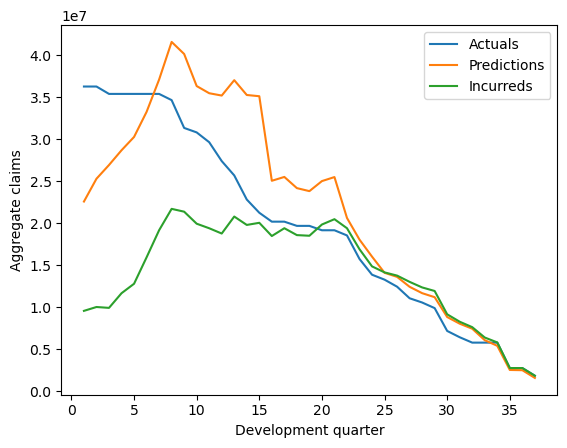

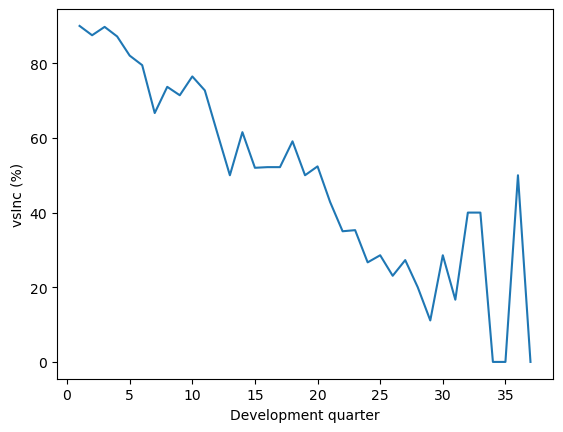

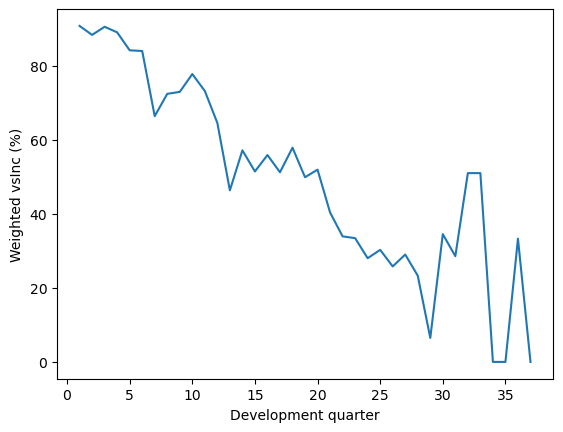

Small Latest
Aggregate predictions: 4,203,231
Aggregate actual: 3,710,117
Aggregate incurred: 3,759,796
model MALE: 0.245, MSLE: 0.109
incurred MALE: 0.026, MSLE: 0.003
vsInc: 4.27%
Weighted vsInc: 5.47%
number of preds: 234


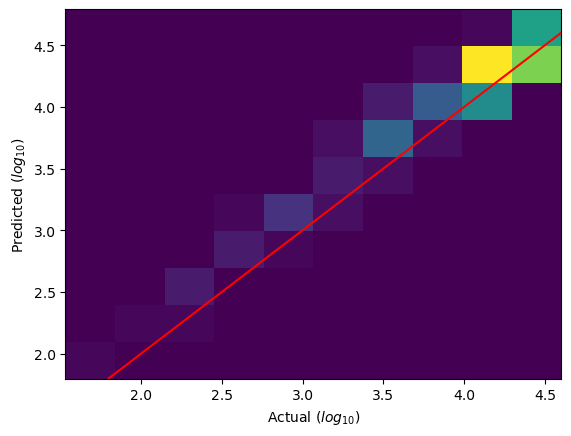

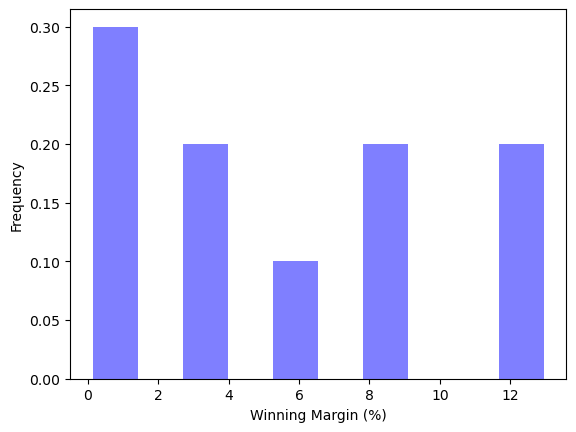

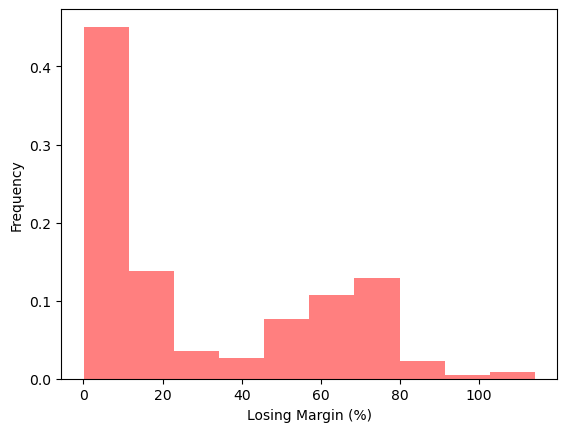

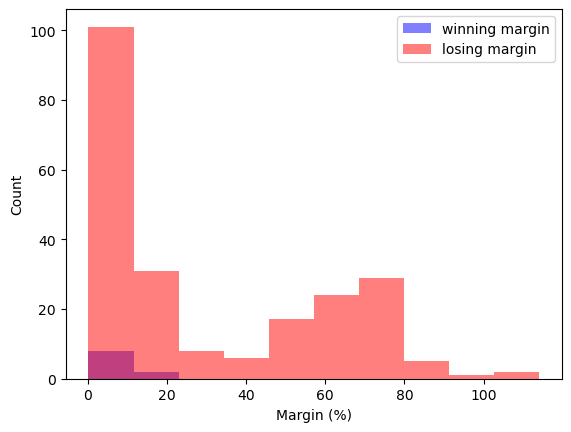

Medium Latest
Aggregate predictions: 44,223,321
Aggregate actual: 43,720,494
Aggregate incurred: 43,306,617
model MALE: 0.150, MSLE: 0.080
incurred MALE: 0.065, MSLE: 0.075
vsInc: 7.53%
Weighted vsInc: 6.79%
number of preds: 292


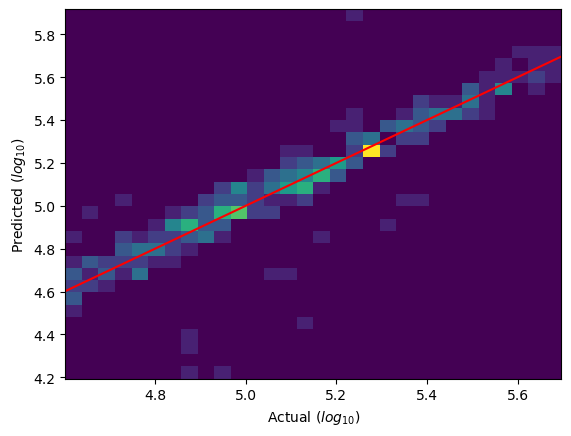

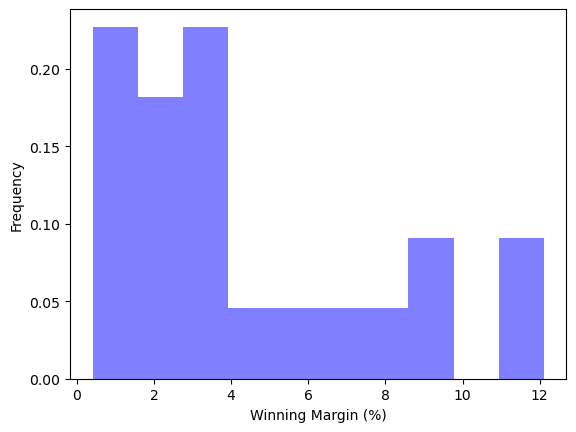

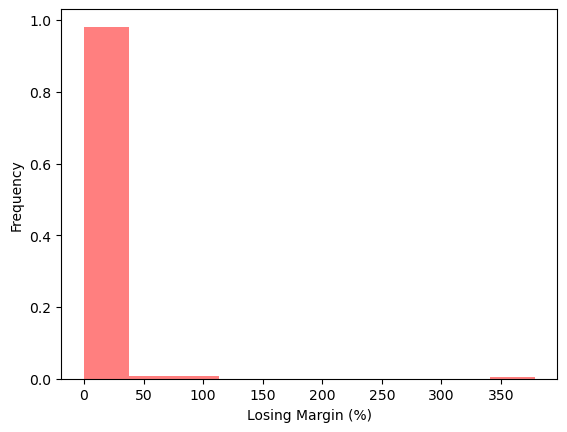

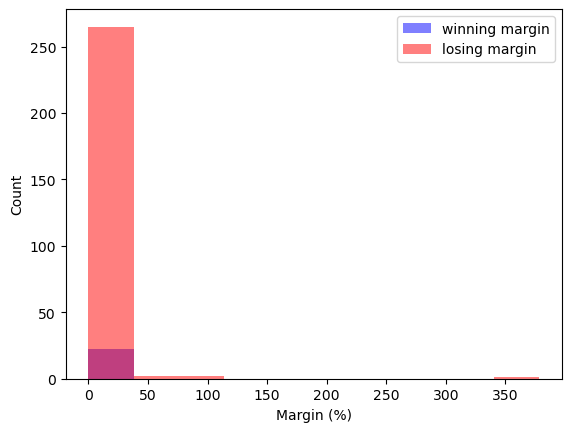

Large Latest
Aggregate predictions: 33,726,146
Aggregate actual: 36,270,783
Aggregate incurred: 36,315,650
model MALE: 0.128, MSLE: 0.032
incurred MALE: 0.031, MSLE: 0.014
vsInc: 5.00%
Weighted vsInc: 5.74%
number of preds: 40


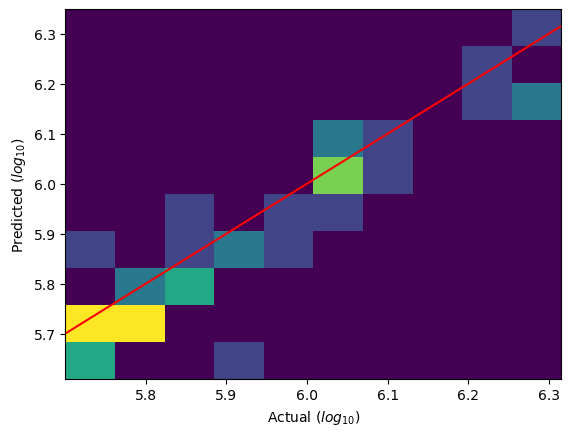

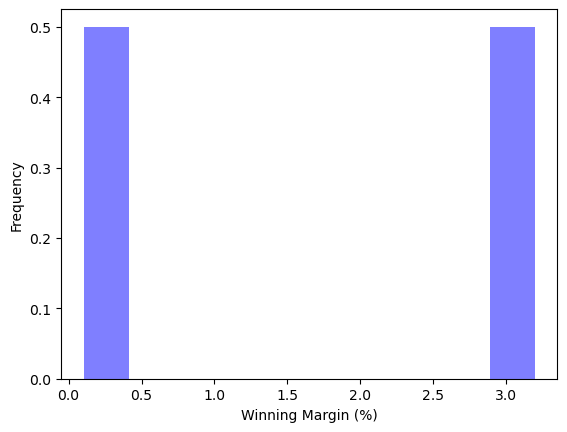

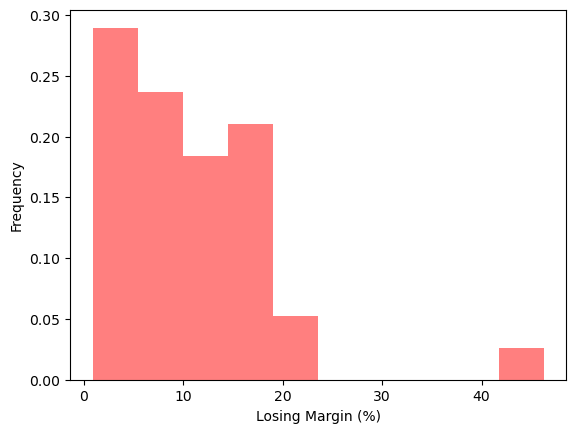

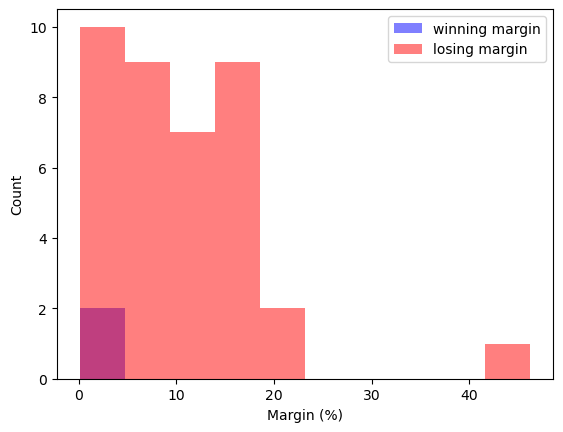

In [3]:
torch.manual_seed(1)

fp_in = 'Datasets/Python Inputs/noInf_WithInc_seed_20201006/'
fp_out = 'Results/results.csv'

# Hyperparameter values to tune (constants)
target_cols = ['log_m']
criterions = [torch.nn.MSELoss()]
types = ['LSTM']
output_layers = ['linear']
nOuts = [1]
epochss = [200]
nonlinearitys = ['relu']
patiences = [10]
normalisations = [False]
include_incurredss = [False]
include_covariatess = [False]
transform_inputss = [False]
model_types = ['RNN']

# Hyperparameter values to tune (variable)
nHiddens = [256, 512]
nLayerss = [2, 3]
batch_sizes = [512]
dropouts = [0.0, 0.2]
learning_rates = [0.00001, 0.0001, 0.001]


hyperparameter_grid = create_grid(target_cols, criterions, types, 
                                  output_layers, nOuts, epochss, nHiddens, 
                                  nLayerss, patiences, batch_sizes, 
                                  learning_rates, nonlinearitys, dropouts, 
                                  normalisations, include_incurredss, 
                                  include_covariatess, transform_inputss, model_types)

cross_validate(fp_in, fp_out, hyperparameter_grid)

## Test Set